# 03. CodeMirage LR-only with cache-only embeddings and surface-normalization stress tests

## 1. Imports and Configs


In [1]:
!pip -q install datasets transformers sentence-transformers ripser persim


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 843.4/843.4 kB 4.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.2 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import io
import json
import os
import random
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss,
)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

from ripser import ripser


In [3]:
# =========================
# Main configuration
# =========================

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Output folder
OUTPUT_DIR = Path("/kaggle/working/codemirage_lr_only_results")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
CACHE_DIR = OUTPUT_DIR / "cache"
for folder in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, CACHE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


# Kaggle dataset with cached embeddings uploaded as All_TDA_embs.
ALL_TDA_CODEMIRAGE_DIRS = [
    Path("/kaggle/input/All_TDA_embs"),
]

# Loading mode
LOAD_FROM_HUGGINGFACE = True
HF_DATASET_NAME = "HanxiGuo/CodeMirage"
LOCAL_CODEMIRAGE_PATH = Path("/kaggle/input/codemirage/CodeMirage.csv")

# Use all languages by default
LANGUAGE_FILTER = None

# Sampling
MAX_ROWS = 8000
BALANCE_BY_LABEL = True
BALANCE_BY_LANGUAGE = True

# Optional embeddings
USE_EMBEDDINGS = True
EMBEDDING_MODELS = [
    "codebert",
    "graphcodebert",
    "unixcoder",
    "sbert",
]

BATCH_SIZE = 12
MAX_LENGTH = 512
DEVICE = "cuda" if os.environ.get("CUDA_VISIBLE_DEVICES") not in (None, "") else "cpu"

# Cache-only mode: do not recompute embeddings unless this is manually set to True.
ALLOW_EMBEDDING_GENERATION = False

# TDA settings
TOKEN_TDA_MAX_POINTS = 150
BETTI_GRID = 24

# Optional Python-only function-level TDA supplement.
# This is disabled by default because it is much slower.
USE_PYTHON_FUNCTION_TDA = False

# Evaluation settings
TEST_SIZE = 0.20
REPEATED_SPLITS = 5
BOOTSTRAP_ROUNDS = 1000
TOP_K_FOR_FINAL_TEST = 7

# Optional extra evaluation
RUN_LENGTH_MATCHED_EVAL = True

# Final-test and transformed-code stress settings
RUN_ALL_FINAL_CONFIGS = True
RECOMPUTE_TRANSFORMED_HF_EMBEDDINGS = True
TRANSFORMED_HF_MODELS = ["codebert", "graphcodebert", "unixcoder", "sbert"]


print("Embedding generation allowed:", ALLOW_EMBEDDING_GENERATION)


Embedding generation allowed: False


## 2. Load CodeMirage and preprocess

Columns we are interested in:
- `code`
- `language`
- `source`
- `variant`

Labels:
- `Human` -> 0
- any AI generator -> 1


In [4]:
def load_codemirage():
    if LOAD_FROM_HUGGINGFACE:
        from datasets import load_dataset
        ds = load_dataset(HF_DATASET_NAME)
        split = "train" if "train" in ds else list(ds.keys())[0]
        return ds[split].to_pandas()

    if not LOCAL_CODEMIRAGE_PATH.exists():
        raise FileNotFoundError(f"Local CodeMirage file was not found: {LOCAL_CODEMIRAGE_PATH}")
    return pd.read_csv(LOCAL_CODEMIRAGE_PATH)

raw = load_codemirage()
lower = {c.lower(): c for c in raw.columns}

def get_col(candidates):
    for name in candidates:
        if name.lower() in lower:
            return lower[name.lower()]
    return None

code_col = get_col(["code", "text", "content"])
lang_col = get_col(["language", "lang"])
source_col = get_col(["source", "model", "generator"])
variant_col = get_col(["variant", "type"])
group_col = get_col(["group_id", "problem_id", "task_id", "pair_id", "instance_id"])

if code_col is None:
    raise ValueError("No code column was found in the CodeMirage data.")

df = pd.DataFrame()
df["code"] = raw[code_col].fillna("").astype(str)
df["language"] = raw[lang_col].fillna("unknown").astype(str) if lang_col else "unknown"
df["source"] = raw[source_col].fillna("unknown").astype(str) if source_col else "unknown"
df["variant"] = raw[variant_col].fillna("unknown").astype(str) if variant_col else "unknown"

df["label"] = (~df["source"].str.lower().eq("human")).astype(int)
df.loc[df["variant"].str.lower().isin(["n/a", "na", "human"]), "label"] = 0

if group_col is not None:
    df["group_id"] = raw[group_col].astype(str).values
else:
    df["group_id"] = np.arange(len(df)).astype(str)

df = df[df["code"].str.len() > 0].reset_index(drop=True)

if LANGUAGE_FILTER is not None:
    df = df[df["language"].isin(LANGUAGE_FILTER)].copy()

def balanced_sample(dataframe, max_rows=8000, by_label=True, by_language=True, seed=42):
    if len(dataframe) <= max_rows:
        return dataframe.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    if not by_label:
        return dataframe.sample(max_rows, random_state=seed).reset_index(drop=True)

    group_cols = ["label"] + (["language"] if by_language else [])
    parts = []
    groups = list(dataframe.groupby(group_cols))
    target = max(1, max_rows // max(len(groups), 1))

    for _, part in groups:
        parts.append(part.sample(min(len(part), target), random_state=seed))

    out = pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    if len(out) > max_rows:
        out = out.sample(max_rows, random_state=seed).reset_index(drop=True)
    return out

df = balanced_sample(
    df,
    max_rows=MAX_ROWS,
    by_label=BALANCE_BY_LABEL,
    by_language=BALANCE_BY_LANGUAGE,
    seed=RANDOM_SEED,
)

df["row_index"] = np.arange(len(df))
df["n_chars"] = df["code"].str.len()
df["n_lines"] = df["code"].str.count("\n") + 1

print("Final sample shape:", df.shape)
print("Label counts:", Counter(df["label"]))
print("Languages:")
print(df["language"].value_counts().head(20))
print()
print("Top sources:")
print(df["source"].value_counts().head(20))
print()
print("Variants:")
print(df["variant"].value_counts().head(20))
print()
print("Grouping column used:", group_col if group_col is not None else "row index fallback")


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/493M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/211M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/146992 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/62996 [00:00<?, ? examples/s]

Final sample shape: (8000, 9)
Label counts: Counter({0: 4000, 1: 4000})
Languages:
language
Java          800
JavaScript    800
HTML          800
PHP           800
C             800
CSharp        800
Ruby          800
Go            800
CPP           800
Python        800
Name: count, dtype: int64

Top sources:
source
Human                            4000
deepseek-r1                       480
deepseek-v3                       450
qwen2.5-coder                     428
o3-mini                           413
gpt-4o-mini                       412
gemini-2.0-flash-thinking-exp     399
llama3.3-70b                      364
claude-3.5-haiku                  360
gemini-2.0-pro-exp                354
gemini-2.0-flash                  340
Name: count, dtype: int64

Variants:
variant
unknown        4000
Paraphrased    2193
Normal         1807
Name: count, dtype: int64

Grouping column used: row index fallback


## 3. EDA


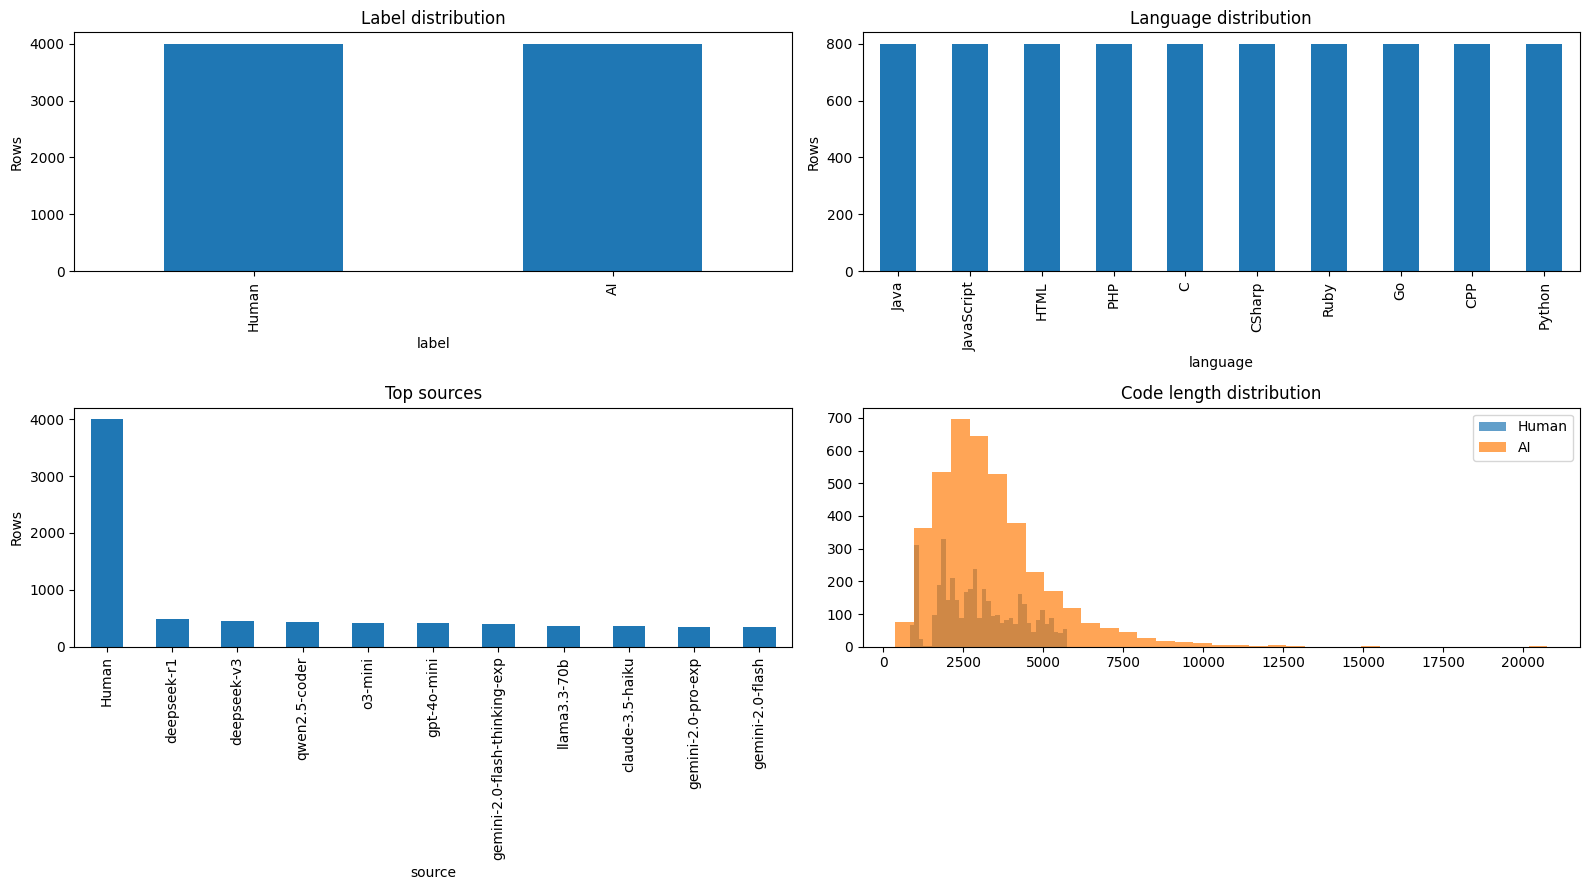

Saved: /kaggle/working/codemirage_lr_only_results/figures/codemirage_eda_overview.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

df["label"].map({0: "Human", 1: "AI"}).value_counts().plot(kind="bar", ax=axes[0, 0], title="Label distribution")
axes[0, 0].set_ylabel("Rows")

df["language"].value_counts().head(15).plot(kind="bar", ax=axes[0, 1], title="Language distribution")
axes[0, 1].set_ylabel("Rows")

df["source"].value_counts().head(15).plot(kind="bar", ax=axes[1, 0], title="Top sources")
axes[1, 0].set_ylabel("Rows")

human_lengths = df.loc[df["label"] == 0, "n_chars"]
ai_lengths = df.loc[df["label"] == 1, "n_chars"]
axes[1, 1].hist(human_lengths, bins=35, alpha=0.7, label="Human")
axes[1, 1].hist(ai_lengths, bins=35, alpha=0.7, label="AI")
axes[1, 1].set_title("Code length distribution")
axes[1, 1].legend()

plt.tight_layout()
fig_path = FIGURE_DIR / "codemirage_eda_overview.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)


## 4. Lexical features и token-level TDA

1. Transform the code into a sequence of tokens;
2. Build a small point cloud from token statistics;
3. Calculate persistent homology.

In [6]:
PY_KEYWORDS = {
    "False", "None", "True", "and", "as", "assert", "async", "await", "break", "class", "continue",
    "def", "del", "elif", "else", "except", "finally", "for", "from", "global", "if", "import",
    "in", "is", "lambda", "nonlocal", "not", "or", "pass", "raise", "return", "try", "while", "with", "yield"
}

GENERIC_KEYWORDS = set(PY_KEYWORDS) | {
    "public", "private", "protected", "static", "final", "void", "int", "long", "float", "double",
    "char", "boolean", "string", "class", "interface", "extends", "implements", "return", "if", "else",
    "for", "while", "do", "switch", "case", "break", "continue", "try", "catch", "finally", "throw",
    "throws", "new", "var", "let", "const", "function", "package", "import", "include", "using", "namespace"
}

TOKEN_RE = re.compile(r"[A-Za-z_][A-Za-z_0-9]*|\d+\.\d+|\d+|==|!=|<=|>=|&&|\|\||[-+*/%=<>()[\]{}.,:;#]")

def normalize_generic_surface(code_text):
    text = str(code_text)
    text = re.sub(r"//.*", "", text)
    text = re.sub(r"/\*.*?\*/", "", text, flags=re.S)
    text = re.sub(r"#.*", "", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n\s*\n+", "\n", text)
    return text.strip() + "\n"

def extract_lexical_features(code_text):
    text = str(code_text)
    lines = text.splitlines()
    nonempty = [ln for ln in lines if ln.strip()]
    tokens = TOKEN_RE.findall(text)
    keyword_count = sum(1 for tok in tokens if tok in GENERIC_KEYWORDS)
    comment_lines = sum(1 for ln in lines if ln.strip().startswith("#") or ln.strip().startswith("//"))
    indent_lengths = [len(ln) - len(ln.lstrip(" ")) for ln in nonempty]
    operator_count = len(re.findall(r"==|!=|<=|>=|\+|-|\*|/|%|=|<|>", text))
    unique_token_ratio = len(set(tokens)) / max(len(tokens), 1)
    return {
        "lex_n_chars": len(text),
        "lex_n_lines": len(lines),
        "lex_n_nonempty_lines": len(nonempty),
        "lex_n_tokens": len(tokens),
        "lex_unique_token_ratio": unique_token_ratio,
        "lex_keyword_ratio": keyword_count / max(len(tokens), 1),
        "lex_comment_line_ratio": comment_lines / max(len(lines), 1),
        "lex_avg_line_length": float(np.mean([len(ln) for ln in lines])) if lines else 0.0,
        "lex_max_line_length": max([len(ln) for ln in lines], default=0),
        "lex_indent_mean": float(np.mean(indent_lengths)) if indent_lengths else 0.0,
        "lex_indent_std": float(np.std(indent_lengths)) if indent_lengths else 0.0,
        "lex_operator_ratio": operator_count / max(len(tokens), 1),
    }

def token_point_cloud(code_text, max_points=150):
    tokens = TOKEN_RE.findall(str(code_text))
    rows = []
    for i, tok in enumerate(tokens[:max_points]):
        is_identifier = 1.0 if re.match(r"^[A-Za-z_][A-Za-z_0-9]*$", tok) else 0.0
        is_keyword = 1.0 if tok in GENERIC_KEYWORDS else 0.0
        tok_len = float(len(tok))
        rows.append([float(i), tok_len, is_identifier + is_keyword])
    if not rows:
        rows = [[0.0, 0.0, 0.0], [0.001, 0.001, 0.001]]
    elif len(rows) == 1:
        rows.append([rows[0][0] + 1e-3, rows[0][1] + 1e-3, rows[0][2] + 1e-3])
    return np.array(rows, dtype=np.float32)

def compute_diagram(cloud):
    try:
        return ripser(cloud, maxdim=1)["dgms"]
    except Exception:
        return [np.array([[0.0, 0.0]]), np.array([[0.0, 0.0]])]

def finite_pairs(diagram):
    if diagram is None or len(diagram) == 0:
        return np.empty((0, 2))
    arr = np.asarray(diagram, dtype=float)
    arr = arr[np.isfinite(arr).all(axis=1)]
    arr = arr[arr[:, 1] > arr[:, 0]]
    return arr

def entropy_from_pairs(pairs):
    pers = pairs[:, 1] - pairs[:, 0]
    if len(pers) == 0 or np.sum(pers) <= 0:
        return 0.0
    p = pers / np.sum(pers)
    return float(-(p * np.log(p + 1e-12)).sum())

def diagram_summary_features(diagrams):
    row = {}
    for dim in [0, 1]:
        pairs = finite_pairs(diagrams[dim]) if dim < len(diagrams) else np.empty((0, 2))
        pers = pairs[:, 1] - pairs[:, 0] if len(pairs) else np.array([])
        row[f"tda_h{dim}_count"] = int(len(pairs))
        row[f"tda_h{dim}_sum_persistence"] = float(pers.sum()) if len(pers) else 0.0
        row[f"tda_h{dim}_max_persistence"] = float(pers.max()) if len(pers) else 0.0
        row[f"tda_h{dim}_mean_persistence"] = float(pers.mean()) if len(pers) else 0.0
        row[f"tda_h{dim}_entropy"] = entropy_from_pairs(pairs)
    return row

def betti_curve_features(diagrams, grid_size=24):
    grid = np.linspace(0, 1, grid_size)
    feats = {}
    for dim in [0, 1]:
        pairs = finite_pairs(diagrams[dim]) if dim < len(diagrams) else np.empty((0, 2))
        for i, t in enumerate(grid):
            count = np.sum((pairs[:, 0] <= t) & (pairs[:, 1] > t)) if len(pairs) else 0
            feats[f"betti_h{dim}_{i:02d}"] = float(count)
    return feats

lexical_df = pd.DataFrame([extract_lexical_features(code) for code in df["code"]])
no_length_cols = [
    c for c in lexical_df.columns
    if c not in {"lex_n_chars", "lex_n_lines", "lex_n_nonempty_lines", "lex_n_tokens", "lex_avg_line_length", "lex_max_line_length"}
]
lexical_df.to_csv(CACHE_DIR / "lexical_features.csv", index=False)

tda_diagrams = [compute_diagram(token_point_cloud(code, max_points=TOKEN_TDA_MAX_POINTS)) for code in df["code"]]
tda_summary = pd.DataFrame([diagram_summary_features(d) for d in tda_diagrams])
tda_betti = pd.DataFrame([betti_curve_features(d, BETTI_GRID) for d in tda_diagrams])
tda_all = pd.concat([tda_summary, tda_betti], axis=1)

tda_summary.to_csv(CACHE_DIR / "tda_summary_features.csv", index=False)
tda_betti.to_csv(CACHE_DIR / "tda_betti_features.csv", index=False)

print("Lexical shape:", lexical_df.shape)
print("TDA summary shape:", tda_summary.shape)
print("TDA all shape:", tda_all.shape)


Lexical shape: (8000, 12)
TDA summary shape: (8000, 10)
TDA all shape: (8000, 58)


## 5. Опциональный Python function-level TDA

This is an **additional** and not used in the final implementation branch.

The idea is:
- if the string is in Python,
- extract the functions,
- build a small TDA for each function separately,
- then aggregate the statistics across the functions.

For multi-language, the main branch is still token-level.


In [7]:
python_function_tda = None

if USE_PYTHON_FUNCTION_TDA:
    import ast
    import textwrap

    def extract_python_functions(code_text):
        clean = textwrap.dedent(str(code_text)).strip("\n")
        try:
            tree = ast.parse(clean)
        except Exception:
            return []
        chunks = []
        for node in ast.walk(tree):
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
                segment = ast.get_source_segment(clean, node)
                if segment:
                    chunks.append(segment)
        return chunks

    rows = []
    for language, code in zip(df["language"], df["code"]):
        if str(language).lower() != "python":
            rows.append({"func_tda_h1_sum_mean": 0.0, "func_tda_h1_entropy_mean": 0.0, "func_count": 0})
            continue

        funcs = extract_python_functions(code)
        if not funcs:
            rows.append({"func_tda_h1_sum_mean": 0.0, "func_tda_h1_entropy_mean": 0.0, "func_count": 0})
            continue

        sums = []
        ents = []
        for func_code in funcs:
            dgm = compute_diagram(token_point_cloud(func_code, max_points=TOKEN_TDA_MAX_POINTS))
            feat = diagram_summary_features(dgm)
            sums.append(feat["tda_h1_sum_persistence"])
            ents.append(feat["tda_h1_entropy"])

        rows.append({
            "func_tda_h1_sum_mean": float(np.mean(sums)),
            "func_tda_h1_entropy_mean": float(np.mean(ents)),
            "func_count": int(len(funcs)),
        })

    python_function_tda = pd.DataFrame(rows)
    python_function_tda.to_csv(CACHE_DIR / "python_function_tda.csv", index=False)
    display(python_function_tda.head())
else:
    print("Function-level Python TDA is disabled.")


Function-level Python TDA is disabled.


## 6. Load cached embeddings or generate

In [8]:
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

from tqdm.auto import tqdm

feature_blocks = {
    "lexical_full": lexical_df.values.astype(np.float32),
    "lexical_no_length": lexical_df[no_length_cols].values.astype(np.float32),
    "tda_summary": tda_summary.values.astype(np.float32),
    "tda_betti": tda_betti.values.astype(np.float32),
    "tda_all": tda_all.values.astype(np.float32),
}

if python_function_tda is not None:
    feature_blocks["python_function_tda"] = python_function_tda.values.astype(np.float32)

MODEL_NAMES = {
    "codebert": "microsoft/codebert-base",
    "graphcodebert": "microsoft/graphcodebert-base",
    "unixcoder": "microsoft/unixcoder-base",
    "sbert": "sentence-transformers/all-MiniLM-L6-v2",
}

EMBEDDING_FILES = {
    "codebert": ["codebert_embeddings.npy", "codebert_embeddings"],
    "graphcodebert": ["graphcodebert_embeddings.npy", "graphcodebert_embeddings"],
    "unixcoder": ["unixcoder_embeddings.npy", "unixcoder_embeddings"],
    "sbert": ["sbert_embeddings.npy", "sbert_embeddings"],
}

TRANSFORMED_EMBEDDING_FILES = {
    "codebert": ["codebert_syntax_normalized_embeddings.npy", "codebert_syntax_normalized_embeddings", "codebert_syntax_normalized_test_embeddings.npy"],
    "graphcodebert": ["graphcodebert_syntax_normalized_embeddings.npy", "graphcodebert_syntax_normalized_embeddings", "graphcodebert_syntax_normalized_test_embeddings.npy"],
    "unixcoder": ["unixcoder_syntax_normalized_embeddings.npy", "unixcoder_syntax_normalized_embeddings", "unixcoder_syntax_normalized_test_embeddings.npy"],
    "sbert": ["sbert_syntax_normalized_embeddings.npy", "sbert_syntax_normalized_embeddings", "sbert_syntax_normalized_test_embeddings.npy"],
}


def first_existing(base_dirs, filename):
    for base in base_dirs:
        base = Path(base)
        direct = base / filename
        if direct.exists():
            return direct
        if base.exists() and str(base).startswith("/kaggle/input"):
            matches = list(base.rglob(filename))
            if matches:
                return matches[0]
    return None


def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = (last_hidden_state * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-9)
    return summed / denom


def generate_sentence_transformer_embeddings(texts, model_name):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_name, device=DEVICE)
    arr = model.encode(
        list(texts),
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    )
    return np.asarray(arr, dtype=np.float32)


def generate_transformer_embeddings(texts, model_name):
    import torch
    from transformers import AutoTokenizer, AutoModel

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(DEVICE)
    model.eval()

    vectors = []
    with torch.no_grad():
        for start in tqdm(range(0, len(texts), BATCH_SIZE), desc=f"Embedding {model_name}"):
            batch = list(texts[start:start + BATCH_SIZE])
            enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            out = model(**enc)
            pooled = mean_pool(out.last_hidden_state, enc["attention_mask"])
            vectors.append(pooled.detach().cpu().numpy().astype(np.float32))
    return np.vstack(vectors).astype(np.float32)


def find_embedding_file(name, transformed=False):
    files = TRANSFORMED_EMBEDDING_FILES[name] if transformed else EMBEDDING_FILES[name]
    for filename in files:
        found = first_existing(ALL_TDA_CODEMIRAGE_DIRS + [CACHE_DIR], filename)
        if found is not None:
            return found
    return None


def load_or_generate_embedding(name, texts, transformed=False):
    expected_rows = len(texts)
    found = find_embedding_file(name, transformed=transformed)
    if found is not None:
        arr = np.load(found)
        if arr.shape[0] == expected_rows:
            print(f"Loaded {name:14s} {arr.shape} from {found}")
            return arr.astype(np.float32)
        print(f"Cached {name} shape {arr.shape} does not match expected rows {expected_rows}: {found}")

    suffix = "syntax_normalized_embeddings" if transformed else "embeddings"
    cache_path = CACHE_DIR / f"{name}_{suffix}.npy"
    if cache_path.exists():
        arr = np.load(cache_path)
        if arr.shape[0] == expected_rows:
            print(f"Loaded {name:14s} {arr.shape} from {cache_path}")
            return arr.astype(np.float32)

    if not ALLOW_EMBEDDING_GENERATION:
        print(f"Embedding generation is disabled. Missing {name} embeddings will be skipped.")
        return None

    print(f"No valid cached {name} embeddings found. Generating from text because ALLOW_EMBEDDING_GENERATION=True...")
    if name == "sbert":
        arr = generate_sentence_transformer_embeddings(texts, MODEL_NAMES[name])
    else:
        arr = generate_transformer_embeddings(texts, MODEL_NAMES[name])
    np.save(cache_path, arr.astype(np.float32))
    print(f"Saved generated {name}: {arr.shape} -> {cache_path}")
    return arr.astype(np.float32)


# --- Robust cached-embedding resolver --------------------------------------
# This overrides the earlier narrow resolver. Kaggle may mount the same dataset
# under a slug that differs from the dataset title, so we index the whole
# /kaggle/input tree and prefer files from the dataset-specific embedding folder.
GLOBAL_INPUT_FILE_INDEX = None
DATASET_EMBEDDING_HINT = 'codemirage_embs'
EMBEDDING_SEARCH_DIRS = ALL_TDA_CODEMIRAGE_DIRS + [CACHE_DIR]


def build_global_input_file_index():
    global GLOBAL_INPUT_FILE_INDEX
    if GLOBAL_INPUT_FILE_INDEX is not None:
        return GLOBAL_INPUT_FILE_INDEX
    index = {}
    root = Path("/kaggle/input")
    if root.exists():
        for path in root.rglob("*"):
            if path.is_file():
                index.setdefault(path.name, []).append(path)
    GLOBAL_INPUT_FILE_INDEX = index
    print(f"Indexed {sum(len(v) for v in index.values())} files under /kaggle/input for embedding lookup.")
    return index


def _score_embedding_path(path: Path, transformed: bool) -> tuple:
    lower = str(path).lower()
    score = 0
    if DATASET_EMBEDDING_HINT.lower() in lower:
        score += 100
    if "/embs/" in lower or "\\embs\\" in lower:
        score += 20
    if transformed and "syntax" in lower:
        score += 10
    if not transformed and "syntax" not in lower:
        score += 5
    return (-score, len(str(path)), str(path))


def find_embedding_candidates(name: str, transformed: bool = False) -> list[Path]:
    files = TRANSFORMED_EMBEDDING_FILES[name] if transformed else EMBEDDING_FILES[name]
    candidates = []

    # Direct and recursive search in known roots.
    for filename in files:
        for base in EMBEDDING_SEARCH_DIRS:
            base = Path(base)
            direct = base / filename
            if direct.exists():
                candidates.append(direct)
            if base.exists() and str(base).startswith("/kaggle/input"):
                candidates.extend(base.rglob(filename))

    # Global fallback across all mounted Kaggle inputs.
    file_index = build_global_input_file_index()
    for filename in files:
        candidates.extend(file_index.get(filename, []))

    # De-duplicate and prefer the right dataset subfolder.
    unique = []
    seen = set()
    for p in candidates:
        p = Path(p)
        key = str(p.resolve()) if p.exists() else str(p)
        if key not in seen:
            seen.add(key)
            unique.append(p)
    return sorted(unique, key=lambda p: _score_embedding_path(p, transformed))


def find_embedding_file(name: str, transformed: bool = False):
    candidates = find_embedding_candidates(name, transformed=transformed)
    return candidates[0] if candidates else None


def load_or_generate_embedding(name: str, texts: Sequence[str], transformed: bool = False) -> Optional[np.ndarray]:
    expected_rows = len(texts)
    candidates = find_embedding_candidates(name, transformed=transformed)
    if candidates:
        print(f"Candidate cached files for {name} (transformed={transformed}):")
        for p in candidates[:5]:
            print("  ", p)
    else:
        print(f"No cached file candidates found for {name} (transformed={transformed}).")

    for found in candidates:
        try:
            arr = np.load(found)
        except Exception as exc:
            print(f"Could not load {found}: {exc}")
            continue
        if arr.shape[0] == expected_rows:
            print(f"Loaded {name:14s} {arr.shape} from {found}")
            return arr.astype(np.float32)
        print(f"Shape mismatch for {name}: {arr.shape}; expected rows {expected_rows} -> {found}")

    suffix = "syntax_normalized_embeddings" if transformed else "embeddings"
    cache_path = CACHE_DIR / f"{name}_{suffix}.npy"
    if cache_path.exists():
        arr = np.load(cache_path)
        if arr.shape[0] == expected_rows:
            print(f"Loaded {name:14s} {arr.shape} from {cache_path}")
            return arr.astype(np.float32)
        print(f"Shape mismatch for cache {cache_path}: {arr.shape}; expected rows {expected_rows}")

    if name == "ada":
        print("Ada embeddings were not found and cannot be generated in this notebook.")
        return None
    if name not in MODEL_NAMES:
        print(f"No generator is configured for {name}.")
        return None
    if not ALLOW_EMBEDDING_GENERATION:
        print(f"Embedding generation is disabled. Missing valid {name} embeddings will be skipped.")
        return None

    print(f"No valid cached {name} embeddings found. Generating from text because ALLOW_EMBEDDING_GENERATION=True...")
    if name == "sbert":
        arr = generate_sentence_transformer_embeddings(texts, MODEL_NAMES[name])
    else:
        arr = generate_transformer_embeddings(texts, MODEL_NAMES[name])
    np.save(cache_path, arr.astype(np.float32))
    print(f"Saved generated {name}: {arr.shape} -> {cache_path}")
    return arr.astype(np.float32)
# ---------------------------------------------------------------------------

if USE_EMBEDDINGS:
    texts = df["code"].astype(str).tolist()
    for name in EMBEDDING_MODELS:
        arr = load_or_generate_embedding(name, texts, transformed=False)
        if arr is None:
            continue
        if arr.shape[0] != len(df):
            print(f"Skipping {name}: shape {arr.shape} does not match rows {len(df)}")
            continue
        feature_blocks[name] = arr.astype(np.float32)
        print(f"Ready {name}: {arr.shape}")


Indexed 28 files under /kaggle/input for embedding lookup.
Candidate cached files for codebert (transformed=False):
   /kaggle/input/datasets/caxapb/all-tda-embs/embs/codemirage_embs/codebert_embeddings.npy
   /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/codebert_embeddings.npy
   /kaggle/input/datasets/caxapb/tda-embs-human-like/duplicates and embs/codebert_embeddings.npy
Loaded codebert       (8000, 768) from /kaggle/input/datasets/caxapb/all-tda-embs/embs/codemirage_embs/codebert_embeddings.npy
Ready codebert: (8000, 768)
Candidate cached files for graphcodebert (transformed=False):
   /kaggle/input/datasets/caxapb/all-tda-embs/embs/codemirage_embs/graphcodebert_embeddings.npy
   /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/graphcodebert_embeddings.npy
   /kaggle/input/datasets/caxapb/tda-embs-human-like/duplicates and embs/graphcodebert_embeddings.npy
Loaded graphcodebert  (8000, 768) from /kaggle/input/datasets/caxapb/all-tda-embs/embs/codemirage_

In [9]:
labels = df["label"].astype(int).values
groups = df["group_id"].astype(str).values

EMBEDDING_PRETTY = {
    "codebert": "CodeBERT",
    "graphcodebert": "GraphCodeBERT",
    "unixcoder": "UniXcoder",
    "sbert": "SBERT",
}

def combine_blocks(block_names, blocks_dict=None):
    blocks_dict = feature_blocks if blocks_dict is None else blocks_dict
    return np.hstack([blocks_dict[name] for name in block_names]).astype(np.float32)

def make_lr():
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1200, solver="lbfgs", random_state=RANDOM_SEED)),
        ]
    )

def predict_proba_safe(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))

def metric_dict(y_true, prob):
    pred = (prob >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, prob),
        "pr_auc": average_precision_score(y_true, prob),
        "mcc": matthews_corrcoef(y_true, pred),
        "brier": brier_score_loss(y_true, prob),
    }

configs = [
    {"name": "Lexical-full", "blocks": ["lexical_full"], "model": "lr", "embedding_family": "none"},
    {"name": "Lexical-no-length", "blocks": ["lexical_no_length"], "model": "lr", "embedding_family": "none"},
    {"name": "TDA-summary", "blocks": ["tda_summary"], "model": "lr", "embedding_family": "none"},
    {"name": "TDA-all", "blocks": ["tda_all"], "model": "lr", "embedding_family": "none"},
    {"name": "Lexical-full + TDA-summary", "blocks": ["lexical_full", "tda_summary"], "model": "lr", "embedding_family": "none"},
    {"name": "Lexical-full + TDA-all", "blocks": ["lexical_full", "tda_all"], "model": "lr", "embedding_family": "none"},
    {"name": "Lexical-no-length + TDA-summary", "blocks": ["lexical_no_length", "tda_summary"], "model": "lr", "embedding_family": "none"},
    {"name": "Lexical-no-length + TDA-all", "blocks": ["lexical_no_length", "tda_all"], "model": "lr", "embedding_family": "none"},
]

for emb in EMBEDDING_MODELS:
    if emb not in feature_blocks:
        continue
    pretty = EMBEDDING_PRETTY.get(emb, emb)
    configs.extend([
        {"name": f"{pretty}", "blocks": [emb], "model": "lr", "embedding_family": pretty},
        {"name": f"{pretty} + Lexical", "blocks": [emb, "lexical_full"], "model": "lr", "embedding_family": pretty},
        {"name": f"{pretty} + TDA-summary", "blocks": [emb, "tda_summary"], "model": "lr", "embedding_family": pretty},
        {"name": f"{pretty} + TDA-all", "blocks": [emb, "tda_all"], "model": "lr", "embedding_family": pretty},
        {"name": f"{pretty} + Lexical + TDA-summary", "blocks": [emb, "lexical_full", "tda_summary"], "model": "lr", "embedding_family": pretty},
        {"name": f"{pretty} + Lexical + TDA-all", "blocks": [emb, "lexical_full", "tda_all"], "model": "lr", "embedding_family": pretty},
    ])

if "python_function_tda" in feature_blocks and "codebert" in feature_blocks:
    configs += [
        {"name": "CodeBERT + Function-TDA", "blocks": ["codebert", "python_function_tda"], "model": "lr", "embedding_family": "CodeBERT"},
    ]

cfg_by_name = {cfg["name"]: cfg for cfg in configs}
print(f"Total LR-only configurations: {len(configs)}")
for cfg in configs:
    print(cfg["name"], "->", cfg["blocks"])


Total LR-only configurations: 32
Lexical-full -> ['lexical_full']
Lexical-no-length -> ['lexical_no_length']
TDA-summary -> ['tda_summary']
TDA-all -> ['tda_all']
Lexical-full + TDA-summary -> ['lexical_full', 'tda_summary']
Lexical-full + TDA-all -> ['lexical_full', 'tda_all']
Lexical-no-length + TDA-summary -> ['lexical_no_length', 'tda_summary']
Lexical-no-length + TDA-all -> ['lexical_no_length', 'tda_all']
CodeBERT -> ['codebert']
CodeBERT + Lexical -> ['codebert', 'lexical_full']
CodeBERT + TDA-summary -> ['codebert', 'tda_summary']
CodeBERT + TDA-all -> ['codebert', 'tda_all']
CodeBERT + Lexical + TDA-summary -> ['codebert', 'lexical_full', 'tda_summary']
CodeBERT + Lexical + TDA-all -> ['codebert', 'lexical_full', 'tda_all']
GraphCodeBERT -> ['graphcodebert']
GraphCodeBERT + Lexical -> ['graphcodebert', 'lexical_full']
GraphCodeBERT + TDA-summary -> ['graphcodebert', 'tda_summary']
GraphCodeBERT + TDA-all -> ['graphcodebert', 'tda_all']
GraphCodeBERT + Lexical + TDA-summary -> 

## 7. Train / validation / test split



In [10]:
gss_outer = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)
train_val_idx, test_idx = next(gss_outer.split(df, labels, groups=groups))

groups_train_val = groups[train_val_idx]
labels_train_val = labels[train_val_idx]

gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_SEED + 1)
rel_train_idx, rel_val_idx = next(gss_inner.split(df.iloc[train_val_idx], labels_train_val, groups=groups_train_val))

train_idx = train_val_idx[rel_train_idx]
val_idx = train_val_idx[rel_val_idx]

print("train", len(train_idx), Counter(labels[train_idx]))
print("val", len(val_idx), Counter(labels[val_idx]))
print("test", len(test_idx), Counter(labels[test_idx]))


train 5120 Counter({np.int64(0): 2565, np.int64(1): 2555})
val 1280 Counter({np.int64(1): 655, np.int64(0): 625})
test 1600 Counter({np.int64(0): 810, np.int64(1): 790})


## 9. Validation


In [11]:
val_rows = []

for i, cfg in enumerate(configs, start=1):
    print(f"[{i}/{len(configs)}] Validation for {cfg['name']}")
    X = combine_blocks(cfg["blocks"])
    model = make_lr()
    model.fit(X[train_idx], labels[train_idx])
    prob = predict_proba_safe(model, X[val_idx])
    metrics = metric_dict(labels[val_idx], prob)
    val_rows.append({"config": cfg["name"], "blocks": " + ".join(cfg["blocks"]), "model_family": cfg["model"], **metrics})

validation_results = pd.DataFrame(val_rows).sort_values("f1", ascending=False)
validation_results.to_csv(TABLE_DIR / "codemirage_validation_results.csv", index=False)
display(validation_results)


[1/32] Validation for Lexical-full
[2/32] Validation for Lexical-no-length
[3/32] Validation for TDA-summary
[4/32] Validation for TDA-all
[5/32] Validation for Lexical-full + TDA-summary
[6/32] Validation for Lexical-full + TDA-all
[7/32] Validation for Lexical-no-length + TDA-summary
[8/32] Validation for Lexical-no-length + TDA-all
[9/32] Validation for CodeBERT
[10/32] Validation for CodeBERT + Lexical
[11/32] Validation for CodeBERT + TDA-summary
[12/32] Validation for CodeBERT + TDA-all
[13/32] Validation for CodeBERT + Lexical + TDA-summary
[14/32] Validation for CodeBERT + Lexical + TDA-all
[15/32] Validation for GraphCodeBERT
[16/32] Validation for GraphCodeBERT + Lexical
[17/32] Validation for GraphCodeBERT + TDA-summary
[18/32] Validation for GraphCodeBERT + TDA-all
[19/32] Validation for GraphCodeBERT + Lexical + TDA-summary
[20/32] Validation for GraphCodeBERT + Lexical + TDA-all
[21/32] Validation for UniXcoder
[22/32] Validation for UniXcoder + Lexical
[23/32] Validation

,config,blocks,model_family,accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,brier
19,GraphCodeBERT + Lexical + TDA-all,graphcodebert + lexical_full + tda_all,lr,0.875781,0.875758,0.882443,0.879087,0.943040,0.943471,0.751403,0.096933
18,GraphCodeBERT + Lexical + TDA-summary,graphcodebert + lexical_full + tda_summary,lr,0.875000,0.875569,0.880916,0.878234,0.943128,0.943594,0.749841,0.096769
15,GraphCodeBERT + Lexical,graphcodebert + lexical_full,lr,0.873437,0.875190,0.877863,0.876524,0.940871,0.940130,0.746721,0.098987
17,GraphCodeBERT + TDA-all,graphcodebert + tda_all,lr,0.871875,0.868066,0.883969,0.875946,0.940048,0.939358,0.743627,0.100970
16,GraphCodeBERT + TDA-summary,graphcodebert + tda_summary,lr,0.871094,0.867868,0.882443,0.875095,0.940631,0.939719,0.742052,0.100468
14,GraphCodeBERT,graphcodebert,lr,0.871094,0.870091,0.879389,0.874715,0.938247,0.936395,0.742024,0.101895
10,CodeBERT + TDA-summary,codebert + tda_summary,lr,0.861719,0.866564,0.862595,0.864575,0.938975,0.943811,0.723324,0.102303
12,CodeBERT + Lexical + TDA-summary,codebert + lexical_full + tda_summary,lr,0.860938,0.867488,0.859542,0.863497,0.940544,0.946659,0.721815,0.102736
13,CodeBERT + Lexical + TDA-all,codebert + lexical_full + tda_all,lr,0.860156,0.868421,0.856489,0.862414,0.940583,0.946635,0.720322,0.102778
11,CodeBERT + TDA-all,codebert + tda_all,lr,0.859375,0.863706,0.861069,0.862385,0.939078,0.943870,0.718620,0.102138


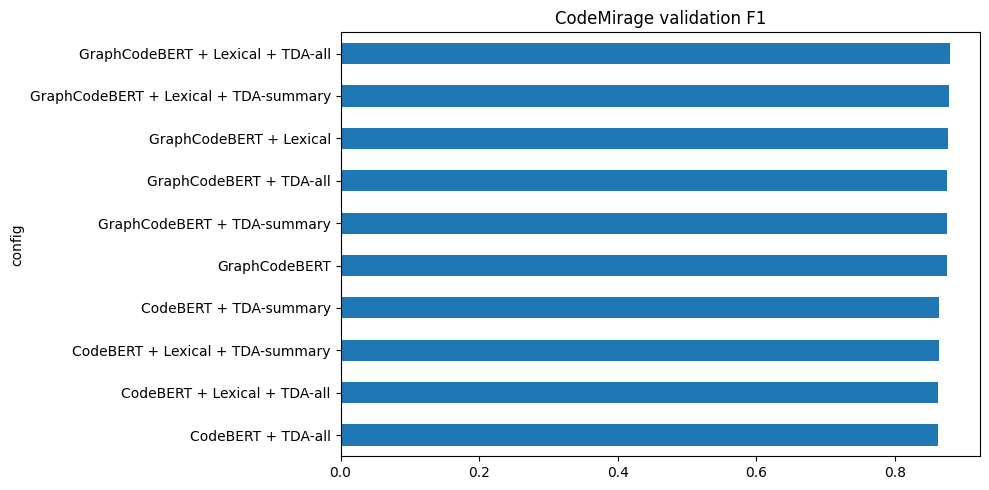

Saved: /kaggle/working/codemirage_lr_only_results/figures/codemirage_validation_f1.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
validation_results.head(10).sort_values("f1").plot(kind="barh", x="config", y="f1", ax=ax, legend=False, title="CodeMirage validation F1")
plt.tight_layout()
fig_path = FIGURE_DIR / "codemirage_validation_f1.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)


## 10. Final test on the best configurations


In [13]:
if RUN_ALL_FINAL_CONFIGS:
    top_configs = validation_results["config"].tolist()
else:
    top_configs = validation_results.head(TOP_K_FOR_FINAL_TEST)["config"].tolist()

print(f"Final test configurations: {len(top_configs)}")

test_rows = []
probs = {}
models_on_trainval = {}
for name in tqdm(top_configs, desc="Final test configurations"):
    cfg = cfg_by_name[name]
    X = combine_blocks(cfg["blocks"])
    model = make_lr()
    model.fit(X[train_val_idx], labels[train_val_idx])
    prob = predict_proba_safe(model, X[test_idx])
    metrics = metric_dict(labels[test_idx], prob)
    test_rows.append({
        "config": cfg["name"],
        "blocks": " + ".join(cfg["blocks"]),
        "model_family": cfg["model"],
        "embedding_family": cfg.get("embedding_family", "none"),
        **metrics,
    })
    probs[cfg["name"]] = prob
    models_on_trainval[cfg["name"]] = model

test_results = pd.DataFrame(test_rows).sort_values("f1", ascending=False)
test_results.to_csv(TABLE_DIR / "codemirage_test_results.csv", index=False)
display(test_results)


Final test configurations: 32


Final test configurations:   0%|          | 0/32 [00:00<?, ?it/s]

,config,blocks,model_family,embedding_family,accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,brier
5,GraphCodeBERT,graphcodebert,lr,GraphCodeBERT,0.858750,0.857868,0.855696,0.856781,0.930258,0.926775,0.717449,0.108816
2,GraphCodeBERT + Lexical,graphcodebert + lexical_full,lr,GraphCodeBERT,0.855000,0.852273,0.854430,0.853350,0.932915,0.932004,0.709966,0.109176
0,GraphCodeBERT + Lexical + TDA-all,graphcodebert + lexical_full + tda_all,lr,GraphCodeBERT,0.850625,0.843945,0.855696,0.849780,0.931355,0.930087,0.701321,0.112490
3,GraphCodeBERT + TDA-all,graphcodebert + tda_all,lr,GraphCodeBERT,0.849375,0.846154,0.849367,0.847757,0.928834,0.925066,0.698722,0.112021
4,GraphCodeBERT + TDA-summary,graphcodebert + tda_summary,lr,GraphCodeBERT,0.849375,0.846154,0.849367,0.847757,0.928922,0.925125,0.698722,0.111908
1,GraphCodeBERT + Lexical + TDA-summary,graphcodebert + lexical_full + tda_summary,lr,GraphCodeBERT,0.848125,0.840598,0.854430,0.847458,0.931352,0.930066,0.696356,0.112338
10,CodeBERT + Lexical,codebert + lexical_full,lr,CodeBERT,0.845000,0.837905,0.850633,0.844221,0.923463,0.923108,0.690087,0.115113
11,CodeBERT,codebert,lr,CodeBERT,0.843750,0.834988,0.851899,0.843358,0.919020,0.918064,0.687667,0.117385
9,CodeBERT + TDA-all,codebert + tda_all,lr,CodeBERT,0.842500,0.833747,0.850633,0.842105,0.917217,0.917257,0.685167,0.119619
8,CodeBERT + Lexical + TDA-all,codebert + lexical_full + tda_all,lr,CodeBERT,0.842500,0.834577,0.849367,0.841907,0.922180,0.922423,0.685125,0.116683


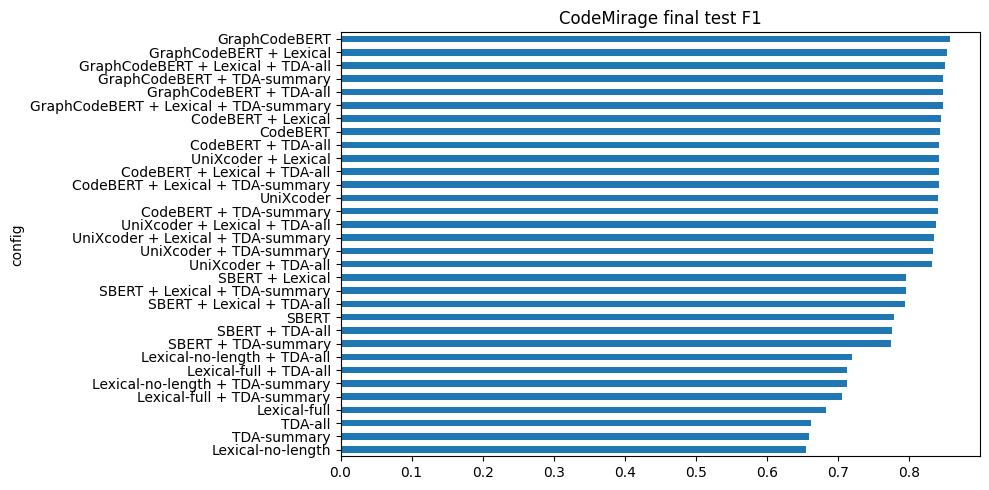

Saved: /kaggle/working/codemirage_lr_only_results/figures/codemirage_test_f1.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
test_results.sort_values("f1").plot(kind="barh", x="config", y="f1", ax=ax, legend=False, title="CodeMirage final test F1")
plt.tight_layout()
fig_path = FIGURE_DIR / "codemirage_test_f1.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)


## 10.1 Paired TDA ablation on CodeMirage

This block compares pairs that differ only by the added TDA feature block. It is the cleanest way to interpret whether the topology block changes decisions on the same test objects.

,A_config,B_config,A_f1,B_f1,delta_f1_B_minus_A,A_roc_auc,B_roc_auc,delta_roc_auc_B_minus_A,A_mcc,B_mcc,delta_mcc_B_minus_A,rescued_by_B,harmed_by_B,mcnemar_p,embedding_family
14,SBERT + Lexical,SBERT + Lexical + TDA-summary,0.795511,0.795256,-0.000255,0.876003,0.873044,-0.002958,0.590355,0.590300,-0.000055,32,32,1.000000,SBERT
15,SBERT + Lexical,SBERT + Lexical + TDA-all,0.795511,0.794282,-0.001229,0.876003,0.873435,-0.002568,0.590355,0.586758,-0.003597,29,32,0.798153,SBERT
1,CodeBERT,CodeBERT + TDA-all,0.843358,0.842105,-0.001253,0.919020,0.917217,-0.001803,0.687667,0.685167,-0.002500,22,24,0.882996,CodeBERT
13,SBERT,SBERT + TDA-all,0.778049,0.776356,-0.001693,0.847592,0.850425,0.002833,0.546893,0.543194,-0.003699,47,50,0.839214,SBERT
3,CodeBERT + Lexical,CodeBERT + Lexical + TDA-all,0.844221,0.841907,-0.002314,0.923463,0.922180,-0.001283,0.690087,0.685125,-0.004963,15,19,0.607591,CodeBERT
0,CodeBERT,CodeBERT + TDA-summary,0.843358,0.840652,-0.002706,0.919020,0.916948,-0.002072,0.687667,0.682624,-0.005042,19,23,0.643969,CodeBERT
2,CodeBERT + Lexical,CodeBERT + Lexical + TDA-summary,0.844221,0.841379,-0.002842,0.923463,0.921883,-0.001580,0.690087,0.683895,-0.006192,15,20,0.499560,CodeBERT
12,SBERT,SBERT + TDA-summary,0.778049,0.774985,-0.003064,0.847592,0.848995,0.001403,0.546893,0.542646,-0.004247,45,48,0.835846,SBERT
7,GraphCodeBERT + Lexical,GraphCodeBERT + Lexical + TDA-all,0.853350,0.849780,-0.003570,0.932915,0.931355,-0.001560,0.709966,0.701321,-0.008645,15,22,0.324009,GraphCodeBERT
11,UniXcoder + Lexical,UniXcoder + Lexical + TDA-all,0.841907,0.837940,-0.003967,0.913418,0.909923,-0.003494,0.685125,0.677586,-0.007538,15,21,0.405032,UniXcoder


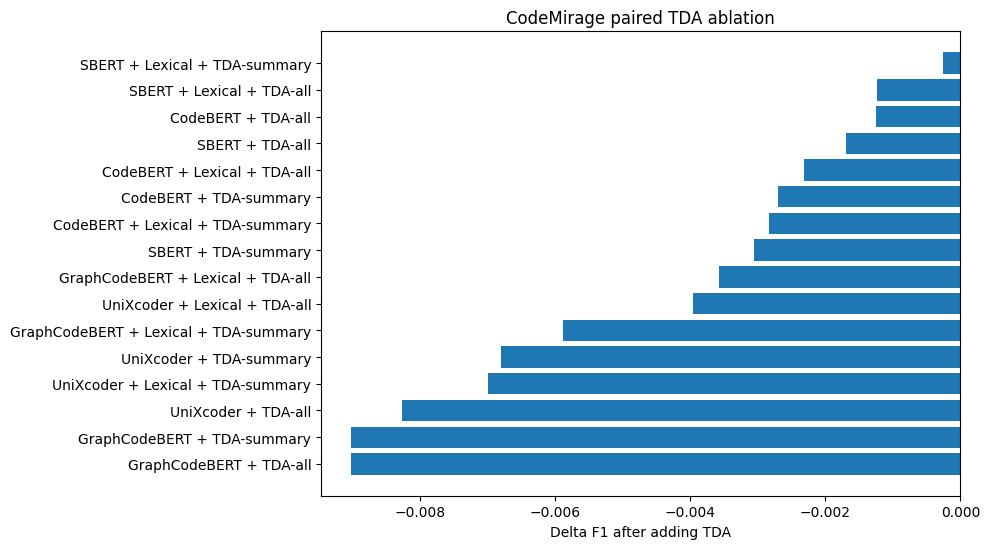

Saved: /kaggle/working/codemirage_lr_only_results/figures/codemirage_paired_tda_ablation_delta_f1.png


In [15]:
def mcnemar_exact_pvalue(y_true, pred_a, pred_b):
    # b: A is wrong and B is correct; c: A is correct and B is wrong
    a_correct = pred_a == y_true
    b_correct = pred_b == y_true
    b = int((~a_correct & b_correct).sum())
    c = int((a_correct & ~b_correct).sum())
    n = b + c
    if n == 0:
        return 1.0, b, c
    try:
        from scipy.stats import binomtest
        p = float(binomtest(min(b, c), n=n, p=0.5, alternative="two-sided").pvalue)
    except Exception:
        # Simple conservative fallback.
        from math import comb
        k = min(b, c)
        p = 2.0 * sum(comb(n, i) for i in range(k + 1)) / (2 ** n)
        p = min(1.0, p)
    return p, b, c

pair_rows = []
test_by_name = test_results.set_index("config")
for emb in EMBEDDING_MODELS:
    pretty = EMBEDDING_PRETTY.get(emb, emb)
    pair_specs = [
        (f"{pretty}", f"{pretty} + TDA-summary"),
        (f"{pretty}", f"{pretty} + TDA-all"),
        (f"{pretty} + Lexical", f"{pretty} + Lexical + TDA-summary"),
        (f"{pretty} + Lexical", f"{pretty} + Lexical + TDA-all"),
    ]
    for a_name, b_name in pair_specs:
        if a_name not in probs or b_name not in probs:
            continue
        pred_a = (probs[a_name] >= 0.5).astype(int)
        pred_b = (probs[b_name] >= 0.5).astype(int)
        p_value, rescued, harmed = mcnemar_exact_pvalue(labels[test_idx], pred_a, pred_b)
        pair_rows.append({
            "A_config": a_name,
            "B_config": b_name,
            "A_f1": float(test_by_name.loc[a_name, "f1"]),
            "B_f1": float(test_by_name.loc[b_name, "f1"]),
            "delta_f1_B_minus_A": float(test_by_name.loc[b_name, "f1"] - test_by_name.loc[a_name, "f1"]),
            "A_roc_auc": float(test_by_name.loc[a_name, "roc_auc"]),
            "B_roc_auc": float(test_by_name.loc[b_name, "roc_auc"]),
            "delta_roc_auc_B_minus_A": float(test_by_name.loc[b_name, "roc_auc"] - test_by_name.loc[a_name, "roc_auc"]),
            "A_mcc": float(test_by_name.loc[a_name, "mcc"]),
            "B_mcc": float(test_by_name.loc[b_name, "mcc"]),
            "delta_mcc_B_minus_A": float(test_by_name.loc[b_name, "mcc"] - test_by_name.loc[a_name, "mcc"]),
            "rescued_by_B": rescued,
            "harmed_by_B": harmed,
            "mcnemar_p": p_value,
            "embedding_family": pretty,
        })

paired_tda = pd.DataFrame(pair_rows).sort_values("delta_f1_B_minus_A", ascending=False)
paired_tda.to_csv(TABLE_DIR / "codemirage_paired_tda_ablation_results.csv", index=False)
display(paired_tda)

if len(paired_tda):
    plot_df = paired_tda.sort_values("delta_f1_B_minus_A")
    fig, ax = plt.subplots(figsize=(10, max(5, len(plot_df) * 0.35)))
    ax.barh(plot_df["B_config"], plot_df["delta_f1_B_minus_A"])
    ax.set_xlabel("Delta F1 after adding TDA")
    ax.set_title("CodeMirage paired TDA ablation")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "codemirage_paired_tda_ablation_delta_f1.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)


## 10.2 TDA feature-volume plots

In [16]:

TDA_VOLUME_BLOCKS = [
    ("no_tda", tuple()),
    ("tda_summary", ("tda_summary",)),
    ("tda_all", ("tda_all",)),
]

volume_rows = []
for emb in tqdm([e for e in EMBEDDING_MODELS if e in feature_blocks], desc="CodeMirage TDA volume by embedding"):
    pretty = EMBEDDING_PRETTY.get(emb, emb)
    for lexical_mode, lexical_blocks in [("embedding_only", tuple()), ("embedding_plus_lexical", ("lexical_full",))]:
        for tda_name, tda_blocks in TDA_VOLUME_BLOCKS:
            blocks = tuple([emb]) + lexical_blocks + tda_blocks
            X = combine_blocks(blocks)
            model = make_lr()
            model.fit(X[train_val_idx], labels[train_val_idx])
            prob = predict_proba_safe(model, X[test_idx])
            metrics = metric_dict(labels[test_idx], prob)
            volume_rows.append({
                "embedding_family": pretty,
                "lexical_mode": lexical_mode,
                "tda_volume": tda_name,
                "n_features_total": int(sum(feature_blocks[b].shape[1] for b in blocks)),
                "n_embedding_features": int(feature_blocks[emb].shape[1]),
                "n_lexical_features": int(sum(feature_blocks[b].shape[1] for b in lexical_blocks)),
                "n_tda_features": int(sum(feature_blocks[b].shape[1] for b in tda_blocks)),
                **metrics,
            })

tda_volume_results = pd.DataFrame(volume_rows)
baseline = (
    tda_volume_results[tda_volume_results["tda_volume"] == "no_tda"]
    [["embedding_family", "lexical_mode", "f1"]]
    .rename(columns={"f1": "baseline_f1"})
)
tda_volume_results = tda_volume_results.merge(baseline, on=["embedding_family", "lexical_mode"], how="left")
tda_volume_results["delta_f1"] = tda_volume_results["f1"] - tda_volume_results["baseline_f1"]
tda_volume_results.to_csv(TABLE_DIR / "codemirage_tda_feature_volume_results.csv", index=False)
tda_volume_results.to_csv(TABLE_DIR / "codemirage_tda_feature_volume_results_with_delta.csv", index=False)

tda_counts_table = pd.DataFrame([
    {
        "tda_volume": name,
        "n_tda_features": int(sum(feature_blocks[b].shape[1] for b in blocks)),
        "blocks": ", ".join(blocks) if blocks else "none",
    }
    for name, blocks in TDA_VOLUME_BLOCKS
])
tda_counts_table.to_csv(TABLE_DIR / "codemirage_tda_feature_counts.csv", index=False)
display(tda_counts_table)
display(tda_volume_results.sort_values(["lexical_mode", "embedding_family", "n_tda_features"]))


CodeMirage TDA volume by embedding:   0%|          | 0/4 [00:00<?, ?it/s]

,tda_volume,n_tda_features,blocks
0,no_tda,0,none
1,tda_summary,10,tda_summary
2,tda_all,58,tda_all


,embedding_family,lexical_mode,tda_volume,n_features_total,n_embedding_features,n_lexical_features,n_tda_features,accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,brier,baseline_f1,delta_f1
0,CodeBERT,embedding_only,no_tda,768,768,0,0,0.843750,0.834988,0.851899,0.843358,0.919020,0.918064,0.687667,0.117385,0.843358,0.000000
1,CodeBERT,embedding_only,tda_summary,778,768,0,10,0.841250,0.833333,0.848101,0.840652,0.916948,0.916898,0.682624,0.119968,0.843358,-0.002706
2,CodeBERT,embedding_only,tda_all,826,768,0,58,0.842500,0.833747,0.850633,0.842105,0.917217,0.917257,0.685167,0.119619,0.843358,-0.001253
6,GraphCodeBERT,embedding_only,no_tda,768,768,0,0,0.858750,0.857868,0.855696,0.856781,0.930258,0.926775,0.717449,0.108816,0.856781,0.000000
7,GraphCodeBERT,embedding_only,tda_summary,778,768,0,10,0.849375,0.846154,0.849367,0.847757,0.928922,0.925125,0.698722,0.111908,0.856781,-0.009023
8,GraphCodeBERT,embedding_only,tda_all,826,768,0,58,0.849375,0.846154,0.849367,0.847757,0.928834,0.925066,0.698722,0.112021,0.856781,-0.009023
18,SBERT,embedding_only,no_tda,384,384,0,0,0.772500,0.750588,0.807595,0.778049,0.847592,0.828909,0.546893,0.159205,0.778049,0.000000
19,SBERT,embedding_only,tda_summary,394,384,0,10,0.770625,0.751486,0.800000,0.774985,0.848995,0.828297,0.542646,0.159140,0.778049,-0.003064
20,SBERT,embedding_only,tda_all,442,384,0,58,0.770625,0.748531,0.806329,0.776356,0.850425,0.828039,0.543194,0.158437,0.778049,-0.001693
12,UniXcoder,embedding_only,no_tda,768,768,0,0,0.841875,0.835206,0.846835,0.840981,0.907973,0.900236,0.683820,0.124245,0.840981,0.000000


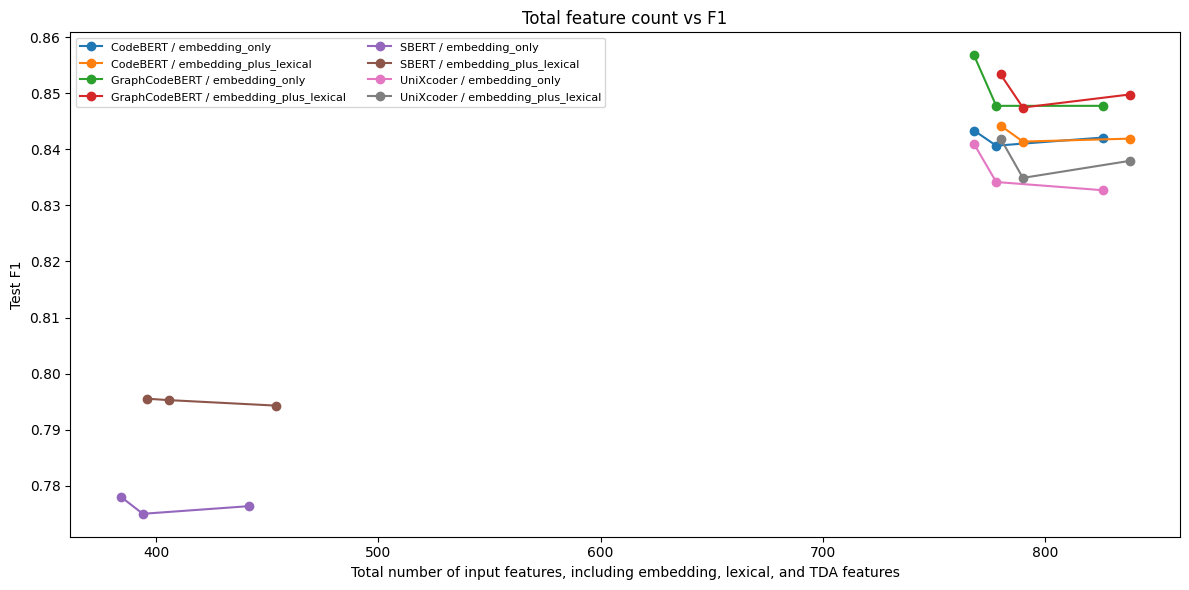

Saved: /kaggle/working/codemirage_lr_only_results/figures/feature_count_total_vs_f1.png


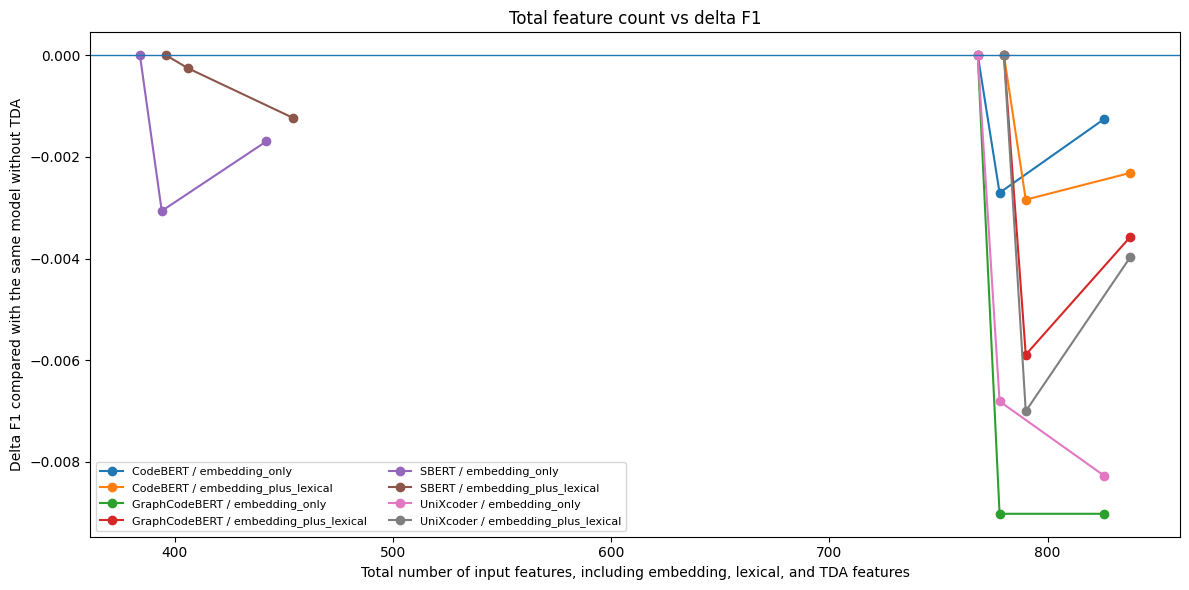

Saved: /kaggle/working/codemirage_lr_only_results/figures/feature_count_total_vs_delta_f1.png


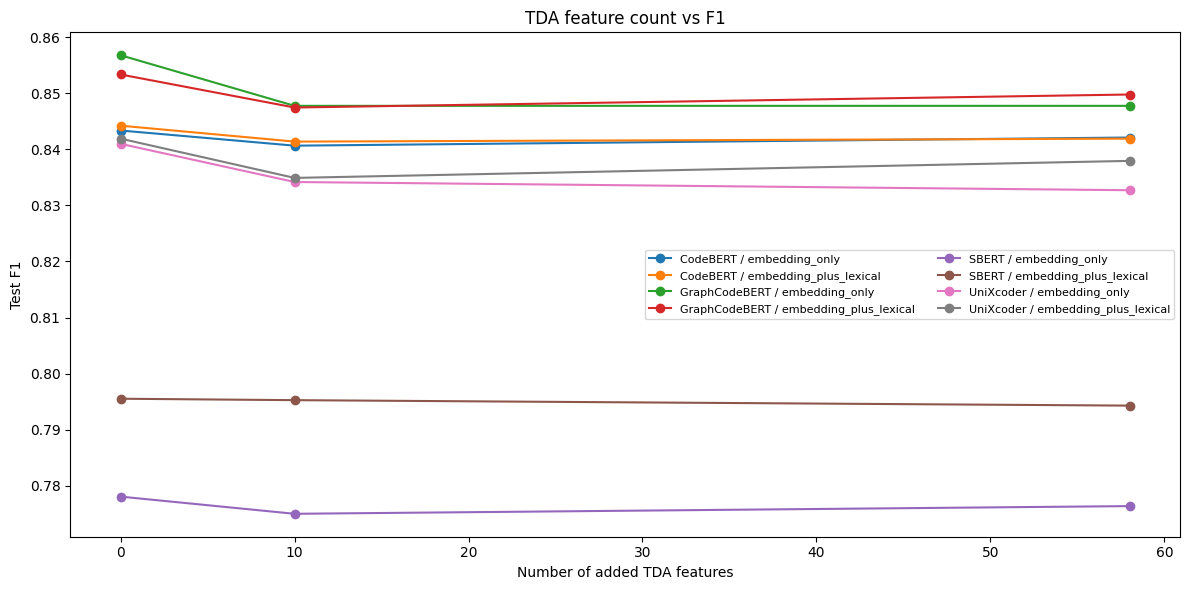

Saved: /kaggle/working/codemirage_lr_only_results/figures/feature_count_tda_vs_f1.png


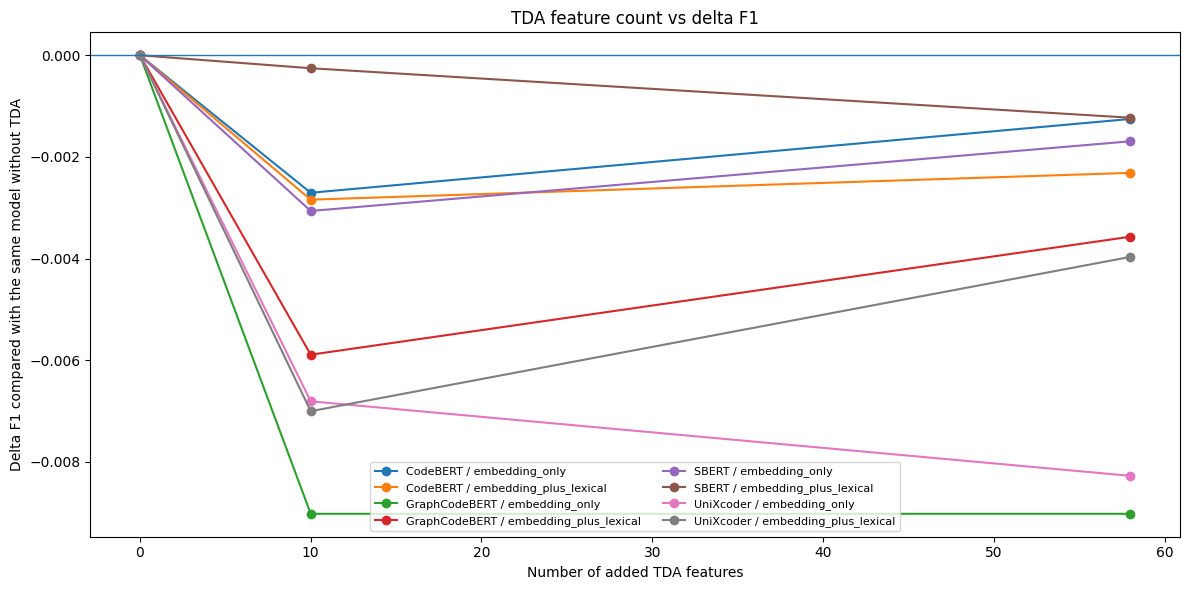

Saved: /kaggle/working/codemirage_lr_only_results/figures/feature_count_tda_vs_delta_f1.png


In [17]:

# Four feature-count plots:
# 1) total feature count -> F1
# 2) total feature count -> delta F1
# 3) added TDA feature count -> F1
# 4) added TDA feature count -> delta F1
# Each plot contains both modes: embedding-only and embedding + lexical.

def plot_volume_metric(x_col, y_col, title, x_label, y_label, filename):
    plt.figure(figsize=(12, 6))
    for (emb, lexical_mode), sub in tda_volume_results.groupby(["embedding_family", "lexical_mode"]):
        s = sub.sort_values([x_col, "tda_volume"])
        label = f"{emb} / {lexical_mode}"
        plt.plot(s[x_col], s[y_col], marker="o", label=label)
    if y_col == "delta_f1":
        plt.axhline(0, linewidth=1)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    fig_path = FIGURE_DIR / filename
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

plot_volume_metric(
    "n_features_total",
    "f1",
    "Total feature count vs F1",
    "Total number of input features, including embedding, lexical, and TDA features",
    "Test F1",
    "feature_count_total_vs_f1.png",
)

plot_volume_metric(
    "n_features_total",
    "delta_f1",
    "Total feature count vs delta F1",
    "Total number of input features, including embedding, lexical, and TDA features",
    "Delta F1 compared with the same model without TDA",
    "feature_count_total_vs_delta_f1.png",
)

plot_volume_metric(
    "n_tda_features",
    "f1",
    "TDA feature count vs F1",
    "Number of added TDA features",
    "Test F1",
    "feature_count_tda_vs_f1.png",
)

plot_volume_metric(
    "n_tda_features",
    "delta_f1",
    "TDA feature count vs delta F1",
    "Number of added TDA features",
    "Delta F1 compared with the same model without TDA",
    "feature_count_tda_vs_delta_f1.png",
)


## 11. Repeated splits и bootstrap


In [18]:
selected = validation_results.head(5)["config"].tolist()
repeat_rows = []

for split_id in range(REPEATED_SPLITS):
    gss_outer = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED + 100 + split_id)
    trv_idx, te_idx = next(gss_outer.split(df, labels, groups=groups))
    gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_SEED + 200 + split_id)
    rel_tr_idx, _ = next(gss_inner.split(df.iloc[trv_idx], labels[trv_idx], groups=groups[trv_idx]))
    tr_idx = trv_idx[rel_tr_idx]

    for name in selected:
        cfg = cfg_by_name[name]
        X = combine_blocks(cfg["blocks"])
        model = make_lr()
        model.fit(X[tr_idx], labels[tr_idx])
        prob = predict_proba_safe(model, X[te_idx])
        metrics = metric_dict(labels[te_idx], prob)
        repeat_rows.append({"split_id": split_id, "config": name, **metrics})

repeat_raw = pd.DataFrame(repeat_rows)
repeat_raw.to_csv(TABLE_DIR / "codemirage_repeated_splits_raw.csv", index=False)

repeat_summary = repeat_raw.groupby("config")[["f1", "roc_auc", "pr_auc", "mcc"]].agg(["mean", "std"])
repeat_summary.columns = ["_".join(col) for col in repeat_summary.columns]
repeat_summary = repeat_summary.reset_index().sort_values("f1_mean", ascending=False)
repeat_summary.to_csv(TABLE_DIR / "codemirage_repeated_splits_summary.csv", index=False)
display(repeat_summary)

best_name = test_results.iloc[0]["config"]
best_prob = probs[best_name]

rng = np.random.default_rng(RANDOM_SEED)
boot_rows = []
for _ in range(BOOTSTRAP_ROUNDS):
    sample_ids = rng.integers(0, len(test_idx), size=len(test_idx))
    y_bs = labels[test_idx][sample_ids]
    p_bs = best_prob[sample_ids]
    boot_rows.append(metric_dict(y_bs, p_bs))

boot = pd.DataFrame(boot_rows)
boot_ci = []
for metric in ["f1", "roc_auc", "pr_auc", "mcc"]:
    boot_ci.append({
        "metric": metric,
        "mean": float(boot[metric].mean()),
        "ci_low": float(np.percentile(boot[metric], 2.5)),
        "ci_high": float(np.percentile(boot[metric], 97.5)),
    })
boot_ci = pd.DataFrame(boot_ci)
boot_ci.to_csv(TABLE_DIR / "codemirage_bootstrap_ci_best_model.csv", index=False)
display(boot_ci)


,config,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,mcc_mean,mcc_std
1,GraphCodeBERT + Lexical + TDA-all,0.865449,0.007110,0.938270,0.005339,0.941200,0.005268,0.728457,0.011618
2,GraphCodeBERT + Lexical + TDA-summary,0.865275,0.007580,0.938283,0.005238,0.941193,0.005121,0.728198,0.012736
0,GraphCodeBERT + Lexical,0.863027,0.006821,0.937579,0.005146,0.940326,0.004854,0.723676,0.013244
4,GraphCodeBERT + TDA-summary,0.861022,0.010227,0.934346,0.006195,0.935924,0.005393,0.720842,0.019081
3,GraphCodeBERT + TDA-all,0.860772,0.010649,0.934254,0.006159,0.935817,0.005335,0.720340,0.019949


,metric,mean,ci_low,ci_high
0,f1,0.856724,0.838495,0.872248
1,roc_auc,0.930388,0.919086,0.941255
2,pr_auc,0.926882,0.911341,0.941163
3,mcc,0.717334,0.682939,0.747323


## 12. Paraphrase stress-test

Здесь снова используем только конфигурации, которые отобрались на validation.


In [19]:
variant_lower = df["variant"].fillna("").str.lower()

normal_idx = np.where(((labels == 0) | ((labels == 1) & variant_lower.str.contains("normal"))).values)[0]
paraphrase_idx = np.where(((labels == 0) | ((labels == 1) & variant_lower.str.contains("paraphr"))).values)[0]

paraphrase_rows = []
if len(normal_idx) and len(paraphrase_idx):
    for name in selected:
        cfg = cfg_by_name[name]
        X = combine_blocks(cfg["blocks"])
        model = make_lr()
        model.fit(X[normal_idx], labels[normal_idx])
        prob = predict_proba_safe(model, X[paraphrase_idx])
        metrics = metric_dict(labels[paraphrase_idx], prob)
        paraphrase_rows.append({"config": name, **metrics})

paraphrase_results = pd.DataFrame(paraphrase_rows).sort_values("f1", ascending=False)
paraphrase_results.to_csv(TABLE_DIR / "codemirage_paraphrase_stress_results.csv", index=False)
display(paraphrase_results)


,config,accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,brier
0,GraphCodeBERT + Lexical + TDA-all,0.918941,0.920020,0.844505,0.880647,0.964381,0.952635,0.821170,0.062916
1,GraphCodeBERT + Lexical + TDA-summary,0.918295,0.919026,0.843593,0.879696,0.964429,0.952714,0.819729,0.062876
2,GraphCodeBERT + Lexical,0.916519,0.919000,0.838121,0.876699,0.963440,0.951414,0.815772,0.064158
3,GraphCodeBERT + TDA-all,0.913128,0.916038,0.830825,0.871353,0.960914,0.947909,0.808200,0.066418
4,GraphCodeBERT + TDA-summary,0.912482,0.914200,0.830825,0.870521,0.960945,0.947909,0.806750,0.066437


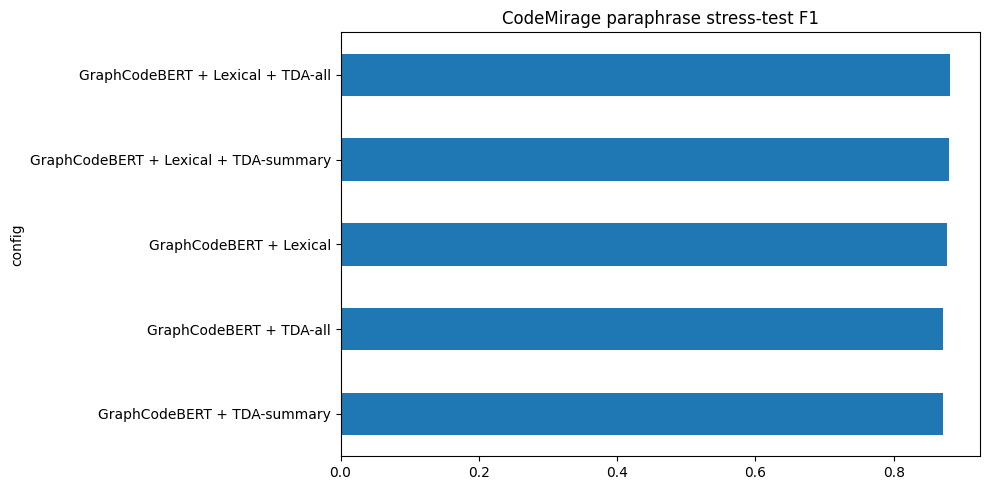

Saved: /kaggle/working/codemirage_lr_only_results/figures/codemirage_paraphrase_stress_f1.png


In [20]:
if len(paraphrase_results):
    fig, ax = plt.subplots(figsize=(10, 5))
    paraphrase_results.sort_values("f1").plot(kind="barh", x="config", y="f1", ax=ax, legend=False, title="CodeMirage paraphrase stress-test F1")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "codemirage_paraphrase_stress_f1.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)


## 13. Held-out generator


In [21]:
ai_counts = df.loc[df["label"] == 1, "source"].value_counts()
min_ai_rows = max(40, int(ai_counts.median() * 0.5)) if len(ai_counts) else 40

heldout_rows = []
for src in ai_counts[ai_counts >= min_ai_rows].index:
    te_idx = np.where(((labels == 1) & (df["source"].values == src)) | (labels == 0))[0]
    tr_idx = np.where(~(((labels == 1) & (df["source"].values == src))))[0]

    if len(np.unique(labels[te_idx])) < 2:
        continue

    for name in selected:
        cfg = cfg_by_name[name]
        X = combine_blocks(cfg["blocks"])
        model = make_lr()
        model.fit(X[tr_idx], labels[tr_idx])
        prob = predict_proba_safe(model, X[te_idx])
        metrics = metric_dict(labels[te_idx], prob)
        base_f1 = float(test_results.loc[test_results["config"] == name, "f1"].iloc[0]) if name in test_results["config"].values else np.nan
        heldout_rows.append({
            "heldout_generator": src,
            "config": name,
            "n_test": len(te_idx),
            **metrics,
            "reference_test_f1": base_f1,
            "generalization_gap_f1": base_f1 - metrics["f1"] if pd.notnull(base_f1) else np.nan,
        })

heldout = pd.DataFrame(heldout_rows)
heldout.to_csv(TABLE_DIR / "codemirage_heldout_generator_results.csv", index=False)
display(heldout.head(20))


,heldout_generator,config,n_test,accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,brier,reference_test_f1,generalization_gap_f1
0,deepseek-r1,GraphCodeBERT + Lexical + TDA-all,4480,0.929018,0.626959,0.833333,0.715564,0.958182,0.842399,0.684871,0.053556,0.849780,0.134217
1,deepseek-r1,GraphCodeBERT + Lexical + TDA-summary,4480,0.928795,0.625978,0.833333,0.714924,0.958113,0.842350,0.684203,0.053625,0.847458,0.132534
2,deepseek-r1,GraphCodeBERT + Lexical,4480,0.927009,0.619718,0.825000,0.707775,0.956733,0.838228,0.675948,0.054626,0.853350,0.145575
3,deepseek-r1,GraphCodeBERT + TDA-all,4480,0.925670,0.613953,0.825000,0.704000,0.952407,0.819410,0.672002,0.057018,0.847757,0.143757
4,deepseek-r1,GraphCodeBERT + TDA-summary,4480,0.925893,0.615265,0.822917,0.704100,0.952364,0.819352,0.671909,0.056987,0.847757,0.143658
5,deepseek-v3,GraphCodeBERT + Lexical + TDA-all,4450,0.935281,0.629808,0.873333,0.731844,0.968663,0.868554,0.708174,0.050851,0.849780,0.117936
6,deepseek-v3,GraphCodeBERT + Lexical + TDA-summary,4450,0.934607,0.626391,0.875556,0.730306,0.968713,0.868740,0.706873,0.050807,0.847458,0.117152
7,deepseek-v3,GraphCodeBERT + Lexical,4450,0.932809,0.619273,0.871111,0.723915,0.967468,0.864788,0.699874,0.051822,0.853350,0.129435
8,deepseek-v3,GraphCodeBERT + TDA-all,4450,0.929213,0.602740,0.880000,0.715447,0.967561,0.863057,0.692447,0.053615,0.847757,0.132310
9,deepseek-v3,GraphCodeBERT + TDA-summary,4450,0.928989,0.601824,0.880000,0.714801,0.967659,0.863315,0.691799,0.053617,0.847757,0.132956


## 14. Syntax normalization stress-test


Normalize CodeMirage test code:   0%|          | 0/1600 [00:00<?, ?it/s]

Transformed lexical:   0%|          | 0/1600 [00:00<?, ?it/s]

Transformed token TDA:   0%|          | 0/1600 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


Candidate transformed files for codebert:
   /kaggle/input/datasets/caxapb/all-tda-embs/embs/codemirage_embs/codebert_syntax_normalized_embeddings.npy
   /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/codebert_syntax_normalized_embeddings.npy
Loaded test-only transformed codebert: (1600, 768) from /kaggle/input/datasets/caxapb/all-tda-embs/embs/codemirage_embs/codebert_syntax_normalized_embeddings.npy
Candidate transformed files for graphcodebert:
   /kaggle/input/datasets/caxapb/all-tda-embs/embs/codemirage_embs/graphcodebert_syntax_normalized_embeddings.npy
   /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/graphcodebert_syntax_normalized_embeddings.npy
Loaded test-only transformed graphcodebert: (1600, 768) from /kaggle/input/datasets/caxapb/all-tda-embs/embs/codemirage_embs/graphcodebert_syntax_normalized_embeddings.npy
Candidate transformed files for unixcoder:
   /kaggle/input/datasets/caxapb/all-tda-embs/embs/codemirage_embs/unixcoder_syntax_normaliz

Syntax-normalization stress configs:   0%|          | 0/32 [00:00<?, ?it/s]

,config,embedding_family,has_embedding,original_f1,transformed_f1,f1_drop,original_roc_auc,transformed_roc_auc,original_mcc,transformed_mcc
1,Lexical-no-length,none,False,0.655260,0.475375,0.179885,0.712877,0.555809,0.319873,0.080584
11,CodeBERT + TDA-all,CodeBERT,True,0.842105,0.670483,0.171622,0.917217,0.744432,0.685167,0.352335
10,CodeBERT + TDA-summary,CodeBERT,True,0.840652,0.669632,0.171021,0.916948,0.746159,0.682624,0.349847
8,CodeBERT,CodeBERT,True,0.843358,0.679076,0.164283,0.919020,0.755191,0.687667,0.374829
15,GraphCodeBERT + Lexical,GraphCodeBERT,True,0.853350,0.701433,0.151918,0.932915,0.746159,0.709966,0.357983
19,GraphCodeBERT + Lexical + TDA-all,GraphCodeBERT,True,0.849780,0.698321,0.151459,0.931355,0.732468,0.701321,0.356180
14,GraphCodeBERT,GraphCodeBERT,True,0.856781,0.706298,0.150483,0.930258,0.751771,0.717449,0.381541
18,GraphCodeBERT + Lexical + TDA-summary,GraphCodeBERT,True,0.847458,0.697863,0.149595,0.931352,0.732897,0.696356,0.354022
0,Lexical-full,none,False,0.682803,0.534759,0.148043,0.754298,0.661538,0.377335,0.250328
16,GraphCodeBERT + TDA-summary,GraphCodeBERT,True,0.847757,0.700592,0.147166,0.928922,0.736698,0.698722,0.372009


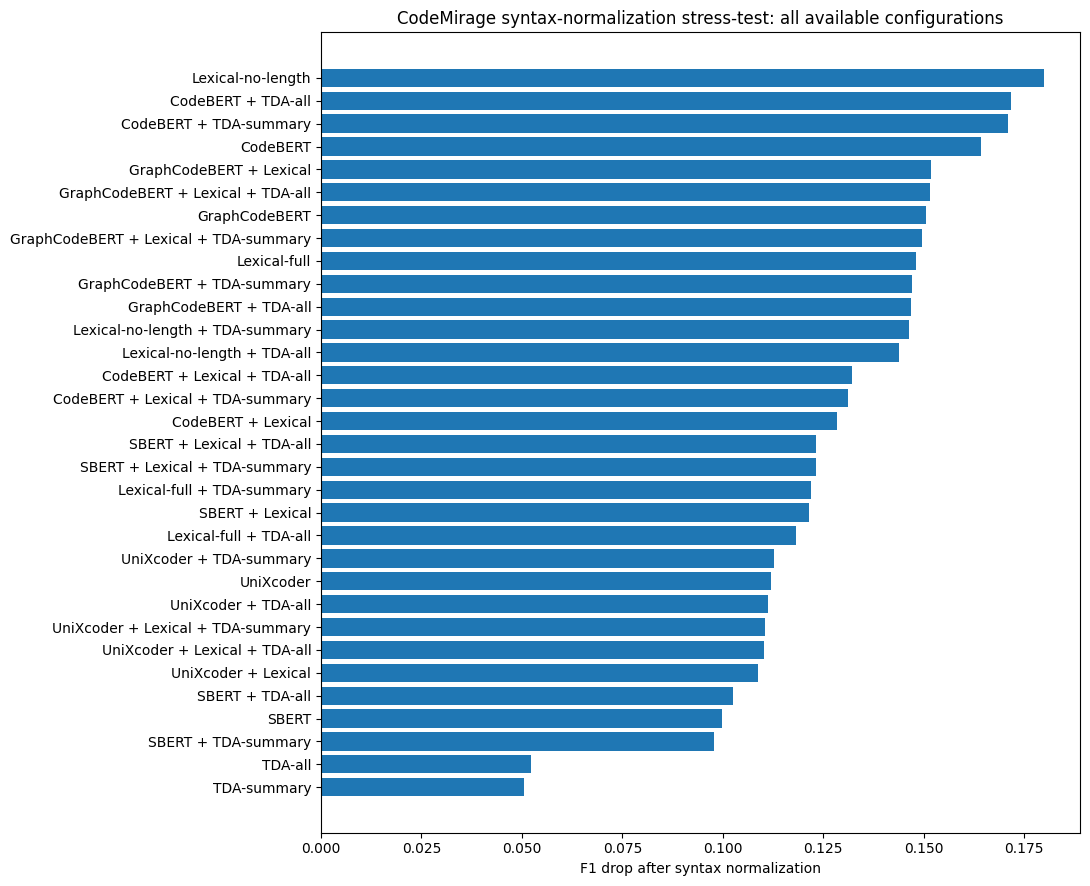

Saved: /kaggle/working/codemirage_lr_only_results/figures/codemirage_syntax_normalization_stress_all_available_configs.png


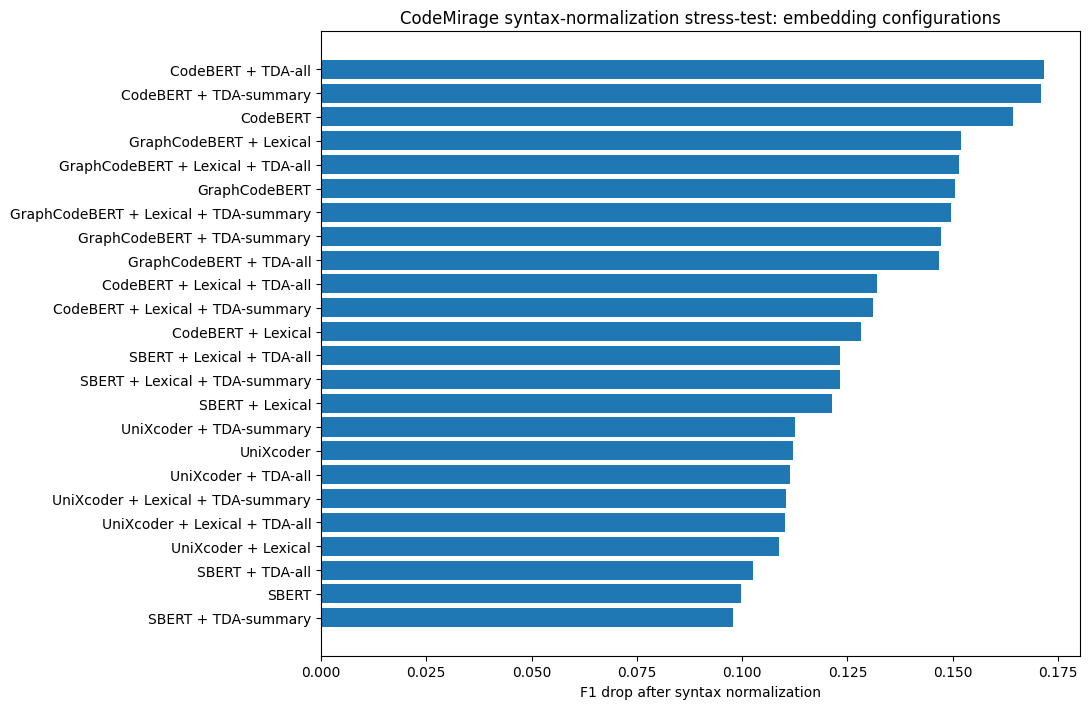

Saved: /kaggle/working/codemirage_lr_only_results/figures/codemirage_syntax_normalization_stress_embedding_configs.png


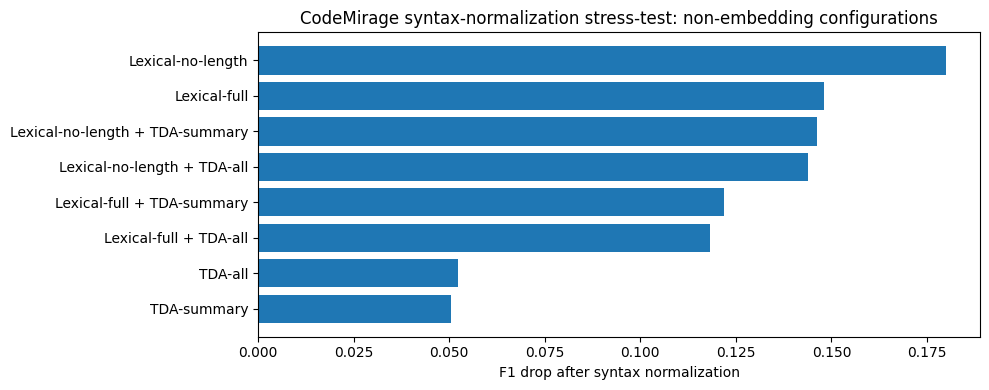

Saved: /kaggle/working/codemirage_lr_only_results/figures/codemirage_syntax_normalization_stress_non_embedding.png


In [22]:

transformed_codes = [normalize_generic_surface(code) for code in tqdm(df.loc[test_idx, "code"], desc="Normalize CodeMirage test code")]

trans_lex = pd.DataFrame([extract_lexical_features(code) for code in tqdm(transformed_codes, desc="Transformed lexical")])
trans_diagrams = [compute_diagram(token_point_cloud(code, max_points=TOKEN_TDA_MAX_POINTS)) for code in tqdm(transformed_codes, desc="Transformed token TDA")]
trans_sum = pd.DataFrame([diagram_summary_features(d) for d in trans_diagrams])
trans_betti = pd.DataFrame([betti_curve_features(d, BETTI_GRID) for d in trans_diagrams])
trans_all = pd.concat([trans_sum, trans_betti], axis=1)

transformed_test_blocks = {
    "lexical_full": trans_lex.values.astype(np.float32),
    "lexical_no_length": trans_lex[no_length_cols].values.astype(np.float32),
    "tda_summary": trans_sum.values.astype(np.float32),
    "tda_betti": trans_betti.values.astype(np.float32),
    "tda_all": trans_all.values.astype(np.float32),
}

for emb in TRANSFORMED_HF_MODELS:
    if emb not in feature_blocks:
        continue
    loaded = False
    candidates = find_embedding_candidates(emb, transformed=True)
    if candidates:
        print(f"Candidate transformed files for {emb}:")
        for p in candidates[:5]:
            print("  ", p)
    else:
        print(f"No cached transformed {emb} embeddings found. Configurations using {emb} are skipped in stress test.")
        continue

    for found in candidates:
        try:
            arr = np.load(found).astype(np.float32)
        except Exception as exc:
            print(f"Could not load transformed {emb} from {found}: {exc}")
            continue
        if arr.shape[0] == len(df):
            transformed_test_blocks[emb] = arr[test_idx]
            print(f"Loaded full transformed {emb}: {arr.shape} -> test rows {transformed_test_blocks[emb].shape} from {found}")
            loaded = True
            break
        elif arr.shape[0] == len(test_idx):
            transformed_test_blocks[emb] = arr
            print(f"Loaded test-only transformed {emb}: {arr.shape} from {found}")
            loaded = True
            break
        else:
            print(f"Shape mismatch for transformed {emb}: {arr.shape}; expected full rows {len(df)} or test rows {len(test_idx)} -> {found}")
    if not loaded:
        print(f"No valid transformed {emb} embedding matrix matched this split/dataset. Configurations using {emb} are skipped.")

syntax_rows = []
skipped_syntax_rows = []
for cfg in tqdm(configs, desc="Syntax-normalization stress configs"):
    missing = [block for block in cfg["blocks"] if block not in transformed_test_blocks]
    if missing:
        skipped_syntax_rows.append({"config": cfg["name"], "missing_transformed_blocks": ", ".join(missing)})
        continue

    X_train_original = combine_blocks(cfg["blocks"])
    X_original_test = X_train_original[test_idx]
    X_transformed_test = combine_blocks(cfg["blocks"], blocks_dict=transformed_test_blocks)

    model = make_lr()
    model.fit(X_train_original[train_val_idx], labels[train_val_idx])
    prob_orig = predict_proba_safe(model, X_original_test)
    prob_trans = predict_proba_safe(model, X_transformed_test)
    m_orig = metric_dict(labels[test_idx], prob_orig)
    m_trans = metric_dict(labels[test_idx], prob_trans)
    has_embedding = any(block in EMBEDDING_MODELS for block in cfg["blocks"])

    syntax_rows.append({
        "config": cfg["name"],
        "embedding_family": cfg.get("embedding_family", "none"),
        "has_embedding": bool(has_embedding),
        "original_f1": m_orig["f1"],
        "transformed_f1": m_trans["f1"],
        "f1_drop": m_orig["f1"] - m_trans["f1"],
        "original_roc_auc": m_orig["roc_auc"],
        "transformed_roc_auc": m_trans["roc_auc"],
        "original_mcc": m_orig["mcc"],
        "transformed_mcc": m_trans["mcc"],
    })

syntax_stress = pd.DataFrame(syntax_rows).sort_values("f1_drop", ascending=False)
skipped_syntax_stress = pd.DataFrame(skipped_syntax_rows)
syntax_stress.to_csv(TABLE_DIR / "codemirage_syntax_normalization_stress.csv", index=False)
skipped_syntax_stress.to_csv(TABLE_DIR / "codemirage_syntax_normalization_stress_skipped_configs.csv", index=False)

syntax_stress_embedding = syntax_stress[syntax_stress["has_embedding"]].copy()
syntax_stress_non_embedding = syntax_stress[~syntax_stress["has_embedding"]].copy()
syntax_stress_embedding.to_csv(TABLE_DIR / "codemirage_syntax_normalization_stress_embedding_configs.csv", index=False)
syntax_stress_non_embedding.to_csv(TABLE_DIR / "codemirage_syntax_normalization_stress_non_embedding.csv", index=False)

display(syntax_stress)
if len(skipped_syntax_stress):
    print("Skipped stress-test configurations because transformed feature blocks were unavailable:")
    display(skipped_syntax_stress.head(30))

plot_df = syntax_stress.sort_values("f1_drop")
fig, ax = plt.subplots(figsize=(11, max(5, len(plot_df) * 0.28)))
ax.barh(plot_df["config"], plot_df["f1_drop"])
ax.set_xlabel("F1 drop after syntax normalization")
ax.set_title("CodeMirage syntax-normalization stress-test: all available configurations")
plt.tight_layout()
fig_path = FIGURE_DIR / "codemirage_syntax_normalization_stress_all_available_configs.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

if len(syntax_stress_embedding):
    plot_df = syntax_stress_embedding.sort_values("f1_drop")
    fig, ax = plt.subplots(figsize=(11, max(5, len(plot_df) * 0.30)))
    ax.barh(plot_df["config"], plot_df["f1_drop"])
    ax.set_xlabel("F1 drop after syntax normalization")
    ax.set_title("CodeMirage syntax-normalization stress-test: embedding configurations")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "codemirage_syntax_normalization_stress_embedding_configs.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

if len(syntax_stress_non_embedding):
    plot_df = syntax_stress_non_embedding.sort_values("f1_drop")
    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.35)))
    ax.barh(plot_df["config"], plot_df["f1_drop"])
    ax.set_xlabel("F1 drop after syntax normalization")
    ax.set_title("CodeMirage syntax-normalization stress-test: non-embedding configurations")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "codemirage_syntax_normalization_stress_non_embedding.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)


## 15. Length-matched evaluation


In [23]:
def length_match_dataframe(dataframe, length_col="n_chars", label_col="label", language_col="language", bin_size=80, seed=42):
    temp = dataframe.copy()
    temp["len_bin"] = (temp[length_col] // bin_size).astype(int)

    parts = []
    for _, part in temp.groupby([language_col, "len_bin"]):
        part0 = part[part[label_col] == 0]
        part1 = part[part[label_col] == 1]
        n = min(len(part0), len(part1))
        if n == 0:
            continue
        parts.append(part0.sample(n, random_state=seed))
        parts.append(part1.sample(n, random_state=seed))

    if not parts:
        return temp.iloc[:0].copy()

    out = pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

length_matched_results = pd.DataFrame()

if RUN_LENGTH_MATCHED_EVAL:
    matched_df = length_match_dataframe(df, seed=RANDOM_SEED)
    if len(matched_df):
        matched_ids = set(matched_df["row_index"].tolist())
        matched_test_idx = np.array([i for i in test_idx if i in matched_ids])

        if len(matched_test_idx) >= 50:
            rows = []
            for name in selected:
                cfg = cfg_by_name[name]
                X = combine_blocks(cfg["blocks"])
                model = make_lr()
                model.fit(X[train_idx], labels[train_idx])
                prob = predict_proba_safe(model, X[matched_test_idx])
                metrics = metric_dict(labels[matched_test_idx], prob)
                rows.append({"config": name, "n_test": len(matched_test_idx), **metrics})

            length_matched_results = pd.DataFrame(rows).sort_values("f1", ascending=False)
            length_matched_results.to_csv(TABLE_DIR / "codemirage_length_matched_results.csv", index=False)
            display(length_matched_results)


,config,n_test,accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,brier
3,GraphCodeBERT + TDA-all,295,0.823729,0.829630,0.794326,0.811594,0.916552,0.910830,0.646675,0.130561
4,GraphCodeBERT + TDA-summary,295,0.823729,0.834586,0.787234,0.810219,0.917150,0.911610,0.646884,0.129974
0,GraphCodeBERT + Lexical + TDA-all,295,0.820339,0.828358,0.787234,0.807273,0.913144,0.909537,0.639950,0.135887
1,GraphCodeBERT + Lexical + TDA-summary,295,0.820339,0.828358,0.787234,0.807273,0.912913,0.909155,0.639950,0.136203
2,GraphCodeBERT + Lexical,295,0.816949,0.822222,0.787234,0.804348,0.914802,0.910463,0.633054,0.133206


## 16. Calibration and error analysis


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,variant,f1,roc_auc,brier
0,raw,0.832700,0.916901,0.125070
1,platt_calibrated,0.833123,0.916901,0.115795


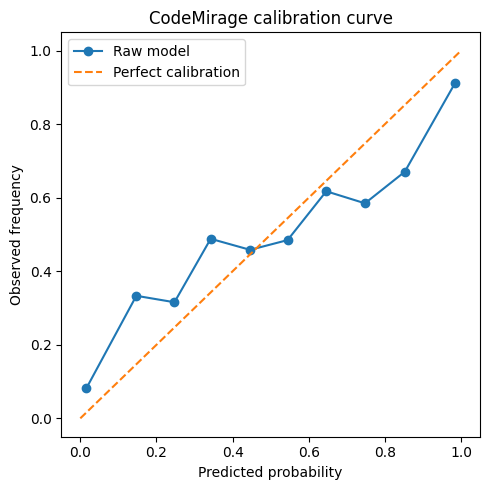

Saved: /kaggle/working/codemirage_lr_only_results/figures/codemirage_calibration_curve.png


,error_type,count
0,true_negative,698
1,true_positive,676
2,false_negative,114
3,false_positive,112


In [24]:
best_name = test_results.iloc[0]["config"]
best_cfg = cfg_by_name[best_name]
X_best = combine_blocks(best_cfg["blocks"])

best_model = make_lr()
best_model.fit(X_best[train_idx], labels[train_idx])

raw_prob = predict_proba_safe(best_model, X_best[test_idx])
calibrated = CalibratedClassifierCV(best_model, method="sigmoid", cv="prefit")
calibrated.fit(X_best[val_idx], labels[val_idx])
cal_prob = calibrated.predict_proba(X_best[test_idx])[:, 1]

calibration_rows = []
for variant, prob in [("raw", raw_prob), ("platt_calibrated", cal_prob)]:
    metrics = metric_dict(labels[test_idx], prob)
    calibration_rows.append({
        "variant": variant,
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
        "brier": metrics["brier"],
    })

calibration_results = pd.DataFrame(calibration_rows)
calibration_results.to_csv(TABLE_DIR / "codemirage_calibration_results.csv", index=False)
display(calibration_results)

prob_true, prob_pred = calibration_curve(labels[test_idx], raw_prob, n_bins=10)
plt.figure(figsize=(5, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Raw model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("CodeMirage calibration curve")
plt.legend()
plt.tight_layout()
fig_path = FIGURE_DIR / "codemirage_calibration_curve.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

best_pred = (probs[best_name] >= 0.5).astype(int)
error_df = df.iloc[test_idx].copy()
error_df["true_label"] = labels[test_idx]
error_df["predicted_label"] = best_pred
error_df["prob_ai"] = probs[best_name]
error_df["error_type"] = np.select(
    [
        (error_df["true_label"] == 0) & (error_df["predicted_label"] == 1),
        (error_df["true_label"] == 1) & (error_df["predicted_label"] == 0),
        (error_df["true_label"] == 1) & (error_df["predicted_label"] == 1),
        (error_df["true_label"] == 0) & (error_df["predicted_label"] == 0),
    ],
    ["false_positive", "false_negative", "true_positive", "true_negative"],
    default="unknown",
)

error_df.to_csv(TABLE_DIR / "codemirage_test_predictions_with_errors.csv", index=False)
error_df[error_df["error_type"] == "false_positive"].to_csv(TABLE_DIR / "codemirage_false_positives.csv", index=False)
error_df[error_df["error_type"] == "false_negative"].to_csv(TABLE_DIR / "codemirage_false_negatives.csv", index=False)

summary = error_df["error_type"].value_counts().rename_axis("error_type").reset_index(name="count")
display(summary)


## 17. Manifest


In [25]:
manifest = {
    "output_dir": str(OUTPUT_DIR),
    "n_rows": int(len(df)),
    "languages": df["language"].value_counts().to_dict(),
    "sources_top20": df["source"].value_counts().head(20).to_dict(),
    "variants": df["variant"].value_counts().to_dict(),
    "embeddings_used": EMBEDDING_MODELS if USE_EMBEDDINGS else [],
    "best_validation_config": validation_results.iloc[0]["config"],
    "best_test_config": test_results.iloc[0]["config"],
    "repeated_splits": REPEATED_SPLITS,
    "max_length": MAX_LENGTH,
    "token_tda_max_points": TOKEN_TDA_MAX_POINTS,
    "python_function_tda_enabled": USE_PYTHON_FUNCTION_TDA,
    "run_all_final_configs": RUN_ALL_FINAL_CONFIGS,
    "transformed_embedding_source": "cache_only",
    "transformed_hf_models": TRANSFORMED_HF_MODELS,
    "classifier": "Logistic Regression only",
    "allow_embedding_generation": bool(ALLOW_EMBEDDING_GENERATION),
    "embedding_loading": "Cache-only. Embeddings are loaded from attached cache folders; missing embeddings are skipped unless ALLOW_EMBEDDING_GENERATION=True.",
}
with open(OUTPUT_DIR / "manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print(json.dumps(manifest, indent=2))
print("Saved:", OUTPUT_DIR / "manifest.json")


{
  "output_dir": "/kaggle/working/codemirage_lr_only_results",
  "n_rows": 8000,
  "languages": {
    "Java": 800,
    "JavaScript": 800,
    "HTML": 800,
    "PHP": 800,
    "C": 800,
    "CSharp": 800,
    "Ruby": 800,
    "Go": 800,
    "CPP": 800,
    "Python": 800
  },
  "sources_top20": {
    "Human": 4000,
    "deepseek-r1": 480,
    "deepseek-v3": 450,
    "qwen2.5-coder": 428,
    "o3-mini": 413,
    "gpt-4o-mini": 412,
    "gemini-2.0-flash-thinking-exp": 399,
    "llama3.3-70b": 364,
    "claude-3.5-haiku": 360,
    "gemini-2.0-pro-exp": 354,
    "gemini-2.0-flash": 340
  },
  "variants": {
    "unknown": 4000,
    "Paraphrased": 2193,
    "Normal": 1807
  },
  "embeddings_used": [
    "codebert",
    "graphcodebert",
    "unixcoder",
    "sbert"
  ],
  "best_validation_config": "GraphCodeBERT + Lexical + TDA-all",
  "best_test_config": "GraphCodeBERT",
  "repeated_splits": 5,
  "max_length": 512,
  "token_tda_max_points": 150,
  "python_function_tda_enabled": false,
  "run

In [26]:
import shutil

archive_path = shutil.make_archive(str(OUTPUT_DIR), "zip", root_dir=OUTPUT_DIR)
print("Archive saved:", archive_path)

Archive saved: /kaggle/working/codemirage_lr_only_results.zip
